# Risk Taker vs Liquidity Provider: Capital Efficiency Analysis

## Question

Is it advantageous to be a **Risk Taker (RT)** in the Liquidity Hedge Protocol compared to simply opening a concentrated liquidity (CL) position as an LP?

We compare **four strategies** deploying the same capital $N$:

| # | Strategy | Capital deployed | Exposure |
|---|----------|-----------------|----------|
| 1 | **Plain LP** | $N in CL position (±5%) | Fees − IL, full price risk |
| 2 | **Hedged LP** | $N in CL + premium for corridor hedge | Fees − IL + payout − premium |
| 3 | **RT v1 (Pure Insurer)** | $N in USDC pool | Premium − claims, no price risk |
| 4 | **RT v2 (Productive Capital)** | $N in wider CL (±10%) | Wider fees + premium + fee share − wider IL − claims |

The key insight is **capital efficiency**: the RT does not need to deploy \$1 for every \$1 of notional hedged. The utilization cap means \$100 of RT capital can back multiple certificates, each earning premiums. We quantify this advantage via Monte Carlo simulation over 10,000 independent 7-day cycles.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import roots_hermite
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(42)
print('Setup complete.')

Setup complete.


In [2]:
# ── Cell 2: CL Value Functions (from pricing_analysis.ipynb) ──

def cl_value_vec(S_arr, L, p_l, p_u):
    """Vectorized CL position value in USD."""
    S = np.atleast_1d(np.asarray(S_arr, dtype=float))
    sp_l, sp_u = np.sqrt(p_l), np.sqrt(p_u)
    sp = np.sqrt(np.clip(S, 1e-10, None))
    below = S <= p_l
    above = S >= p_u
    a = np.where(below, L*(sp_u - sp_l)/(sp_l*sp_u),
        np.where(above, 0.0, L*(sp_u - sp)/(sp*sp_u)))
    b = np.where(below, 0.0,
        np.where(above, L*(sp_u - sp_l), L*(sp - sp_l)))
    return a * S + b

def corridor_payoff_vec(S_T, S0, B, Cap, L, p_l, p_u):
    """Corridor derivative payoff."""
    S_T = np.atleast_1d(np.asarray(S_T, dtype=float))
    S_eff = np.maximum(S_T, B)
    V0 = cl_value_vec(S0, L, p_l, p_u)
    V_eff = cl_value_vec(S_eff, L, p_l, p_u)
    loss = V0 - V_eff
    loss = np.where(S_T >= S0, 0.0, loss)
    return np.minimum(Cap, np.maximum(0.0, loss))

def make_position(S0, width_pct, notional):
    """Create CL position parameters."""
    p_l = S0 * (1 - width_pct)
    p_u = S0 * (1 + width_pct)
    V_per_L = 2*np.sqrt(S0) - S0/np.sqrt(p_u) - np.sqrt(p_l)
    L = notional / V_per_L
    return p_l, p_u, L

def fv_quadrature(S0, sigma, T, r, B, Cap, L, p_l, p_u):
    """No-arbitrage fair value via 64-point Gauss-Hermite."""
    nodes, weights = roots_hermite(64)
    S_T = S0 * np.exp((r - sigma**2/2)*T + sigma*np.sqrt(T)*nodes*np.sqrt(2))
    payoffs = corridor_payoff_vec(S_T, S0, B, Cap, L, p_l, p_u)
    return np.exp(-r*T) * np.sum(weights * payoffs) / np.sqrt(np.pi)

print('Functions loaded.')

Functions loaded.


In [3]:
# ── Cell 3: Market & Protocol Parameters ──

S0 = 130.0            # SOL entry price (USD)
sigma = 0.65          # 65% annualized vol (typical SOL)
T = 7 / 365           # 7-day tenor
r = 0.0               # risk-free rate
N = 10_000            # capital deployed by each strategy ($)

# LP position: ±5% range
lp_width = 0.05
lp_pl, lp_pu, lp_L = make_position(S0, lp_width, N)

# RT v2 position: ±10% range (2x multiplier from protocol)
rt_width = 0.10
rt_pl, rt_pu, rt_L = make_position(S0, rt_width, N)

# Corridor derivative
B = S0 * 0.95         # barrier at 95%
Cap = 500.0           # $500 cap per certificate

# Protocol parameters
u_max = 0.50          # 50% max utilization
fee_share_bps = 1500  # 15% of LP fees go to RT (v2)

# Fee yield assumptions (annualized, from Orca SOL/USDC pool)
lp_fee_apy = 0.25     # 25% APY for ±5% LP (tighter = higher fees)
rt_fee_apy = 0.10     # 10% APY for ±10% RT (wider = lower fees)

# Compute fair value and heuristic premium
fair_value = fv_quadrature(S0, sigma, T, r, B, Cap, lp_L, lp_pl, lp_pu)

# Heuristic premium (with typical on-chain parameters)
# Approximate from on-chain formula: premium ≈ 1.3x fair value (conservative)
premium_multiplier = 1.3
premium = fair_value * premium_multiplier

print(f'=== MARKET PARAMETERS ===')
print(f'  S0 = ${S0:.2f}, sigma = {sigma*100:.0f}%, T = {T*365:.0f} days')
print(f'  Capital per strategy: ${N:,.0f}')
print()
print(f'=== LP POSITION (±{lp_width*100:.0f}%) ===')
print(f'  Range: [${lp_pl:.2f}, ${lp_pu:.2f}], L = {lp_L:.2f}')
print(f'  Fee APY: {lp_fee_apy*100:.0f}%')
print(f'  7-day fee income: ${N * lp_fee_apy * T:.4f}')
print()
print(f'=== RT v2 POSITION (±{rt_width*100:.0f}%) ===')
print(f'  Range: [${rt_pl:.2f}, ${rt_pu:.2f}], L = {rt_L:.2f}')
print(f'  Fee APY: {rt_fee_apy*100:.0f}%')
print(f'  7-day fee income: ${N * rt_fee_apy * T:.4f}')
print()
print(f'=== CORRIDOR DERIVATIVE ===')
print(f'  Barrier: ${B:.2f}, Cap: ${Cap:.2f}')
print(f'  Fair value: ${fair_value:.4f}')
print(f'  Premium charged (1.3x): ${premium:.4f}')

=== MARKET PARAMETERS ===
  S0 = $130.00, sigma = 65%, T = 7 days
  Capital per strategy: $10,000

=== LP POSITION (±5%) ===
  Range: [$123.50, $136.50], L = 17746.85
  Fee APY: 25%
  7-day fee income: $47.9452

=== RT v2 POSITION (±10%) ===
  Range: [$117.00, $143.00], L = 8962.91
  Fee APY: 10%
  7-day fee income: $19.1781

=== CORRIDOR DERIVATIVE ===
  Barrier: $123.50, Cap: $500.00
  Fair value: $149.1731
  Premium charged (1.3x): $193.9250


In [4]:
# ── Cell 4: Capital Efficiency — How Many Certificates Can RT Back? ──

# Key insight: RT capital is NOT 1:1 with certificate cap.
# With u_max = 50%, $10,000 RT capital backs up to $5,000 in active caps.
# Each certificate has Cap = $500, so one RT can back 10 certificates.

max_active_cap = N * u_max
certs_per_rt = int(max_active_cap / Cap)
premium_income_per_cycle = certs_per_rt * premium

print(f'=== CAPITAL EFFICIENCY ===')
print(f'  RT capital:           ${N:,.0f}')
print(f'  Max utilization:      {u_max*100:.0f}%')
print(f'  Max active cap:       ${max_active_cap:,.0f}')
print(f'  Cap per certificate:  ${Cap:.0f}')
print(f'  Certificates backed:  {certs_per_rt}')
print(f'  Premium per cert:     ${premium:.4f}')
print(f'  Total premium/cycle:  ${premium_income_per_cycle:.4f}')
print(f'  Premium yield (7d):   {premium_income_per_cycle/N*100:.4f}%')
print(f'  Premium yield (ann):  {premium_income_per_cycle/N * 365/7 * 100:.2f}%')
print()
print(f'  Compare: LP fee income (7d) = ${N * lp_fee_apy * T:.4f}')
print(f'  Premium income is {premium_income_per_cycle / (N * lp_fee_apy * T):.2f}x the LP fee income')

=== CAPITAL EFFICIENCY ===
  RT capital:           $10,000
  Max utilization:      50%
  Max active cap:       $5,000
  Cap per certificate:  $500
  Certificates backed:  10
  Premium per cert:     $193.9250
  Total premium/cycle:  $1939.2504
  Premium yield (7d):   19.3925%
  Premium yield (ann):  1011.18%

  Compare: LP fee income (7d) = $47.9452
  Premium income is 40.45x the LP fee income


## Monte Carlo: 10,000 Independent 7-Day Cycles

For each cycle we draw a terminal SOL price $S_T$ from GBM and compute the PnL of all four strategies.

**Assumptions:**
- Fee income accrues proportionally over the period (deterministic, based on APY)
- LP's position stays in range if $p_l < S_T < p_u$ (fees accrue only while in range; we approximate by checking terminal price)
- Each RT backs `certs_per_rt` certificates simultaneously (correlated: ALL trigger or NONE, since they reference the same SOL price)
- Corridor payout is per-certificate; RT's total claim = sum across all certificates

In [5]:
# ── Cell 5: Monte Carlo Simulation ──

n_cycles = 100_000
Z = rng.standard_normal(n_cycles)
S_T = S0 * np.exp((r - sigma**2/2)*T + sigma*np.sqrt(T)*Z)

# ── Strategy 1: Plain LP (±5%) ──
lp_V0 = cl_value_vec(S0, lp_L, lp_pl, lp_pu)[0]  # = N
lp_VT = cl_value_vec(S_T, lp_L, lp_pl, lp_pu)
lp_il = lp_VT - lp_V0  # negative = loss
lp_in_range = (S_T > lp_pl) & (S_T < lp_pu)
lp_fees = np.where(lp_in_range, N * lp_fee_apy * T, N * lp_fee_apy * T * 0.1)  # 10% if out of range
pnl_plain_lp = lp_il + lp_fees

# ── Strategy 2: Hedged LP (±5% + corridor) ──
lp_payout = corridor_payoff_vec(S_T, S0, B, Cap, lp_L, lp_pl, lp_pu)
pnl_hedged_lp = lp_il + lp_fees + lp_payout - premium

# ── Strategy 3: RT v1 — Pure Insurer (USDC pool) ──
# RT backs certs_per_rt certificates. Each has the same corridor payoff
# because they all reference the same SOL price.
rt_total_claims = certs_per_rt * lp_payout  # correlated!
rt_total_premiums = premium_income_per_cycle
pnl_rt_v1 = rt_total_premiums - rt_total_claims  # no IL, no price risk

# ── Strategy 4: RT v2 — Productive Capital (±10% CL + insurer) ──
rt_V0 = cl_value_vec(S0, rt_L, rt_pl, rt_pu)[0]  # = N
rt_VT = cl_value_vec(S_T, rt_L, rt_pl, rt_pu)
rt_il = rt_VT - rt_V0
rt_in_range = (S_T > rt_pl) & (S_T < rt_pu)
rt_own_fees = np.where(rt_in_range, N * rt_fee_apy * T, N * rt_fee_apy * T * 0.1)
rt_fee_share = lp_fees * fee_share_bps / 10_000  # share of LP fees
pnl_rt_v2 = rt_il + rt_own_fees + rt_fee_share + rt_total_premiums - rt_total_claims

print(f'Simulated {n_cycles:,} cycles. Terminal price range: ${S_T.min():.2f} — ${S_T.max():.2f}')

Simulated 100,000 cycles. Terminal price range: $87.22 — $203.20


In [6]:
# ── Cell 6: Summary Statistics ──

def summarize(name, pnl, capital=N):
    ret = pnl / capital
    mean_r = np.mean(ret)
    std_r = np.std(ret)
    sharpe = mean_r / std_r if std_r > 0 else np.inf
    var_5 = np.percentile(pnl, 5)
    cvar_5 = np.mean(pnl[pnl <= var_5])
    max_loss = np.min(pnl)
    prob_loss = np.mean(pnl < 0) * 100
    return {
        'Strategy': name,
        'E[PnL]': np.mean(pnl),
        'Std[PnL]': np.std(pnl),
        'E[Return]': mean_r * 100,
        'Std[Return]': std_r * 100,
        'Sharpe (7d)': sharpe,
        'Sharpe (ann)': sharpe * np.sqrt(365/7),
        'VaR 5%': var_5,
        'CVaR 5%': cvar_5,
        'Max Loss': max_loss,
        'P(loss)': prob_loss,
    }

results = [
    summarize('1. Plain LP (±5%)', pnl_plain_lp),
    summarize('2. Hedged LP', pnl_hedged_lp),
    summarize('3. RT v1 (Insurer)', pnl_rt_v1),
    summarize('4. RT v2 (Productive)', pnl_rt_v2),
]

# Print table
print(f'{"":<25} {"E[PnL]":>10} {"Std":>10} {"E[Ret%]":>8} {"Sharpe*":>8} {"VaR5%":>10} {"MaxLoss":>10} {"P(loss)":>8}')
print('─' * 100)
for r in results:
    print(f'{r["Strategy"]:<25} ${r["E[PnL]"]:>9.2f} ${r["Std[PnL]"]:>9.2f} {r["E[Return]"]:>7.3f}% {r["Sharpe (ann)"]:>7.2f} ${r["VaR 5%"]:>9.2f} ${r["Max Loss"]:>9.2f} {r["P(loss)"]:>6.1f}%')

print()
print('* Sharpe ratio annualized (assuming independent weekly cycles)')

                              E[PnL]        Std  E[Ret%]  Sharpe*      VaR5%    MaxLoss  P(loss)
────────────────────────────────────────────────────────────────────────────────────────────────────
1. Plain LP (±5%)         $  -234.80 $   501.53  -2.348%   -3.38 $ -1302.54 $ -3196.93   48.0%
2. Hedged LP              $  -280.69 $   366.85  -2.807%   -5.53 $ -1122.91 $ -3017.30  100.0%
3. RT v1 (Insurer)        $   458.93 $  1684.35   4.589%    1.97 $ -1796.30 $ -1796.30   38.5%
4. RT v2 (Productive)     $   291.69 $  2101.48   2.917%    1.00 $ -2971.83 $ -4894.37   39.2%

* Sharpe ratio annualized (assuming independent weekly cycles)


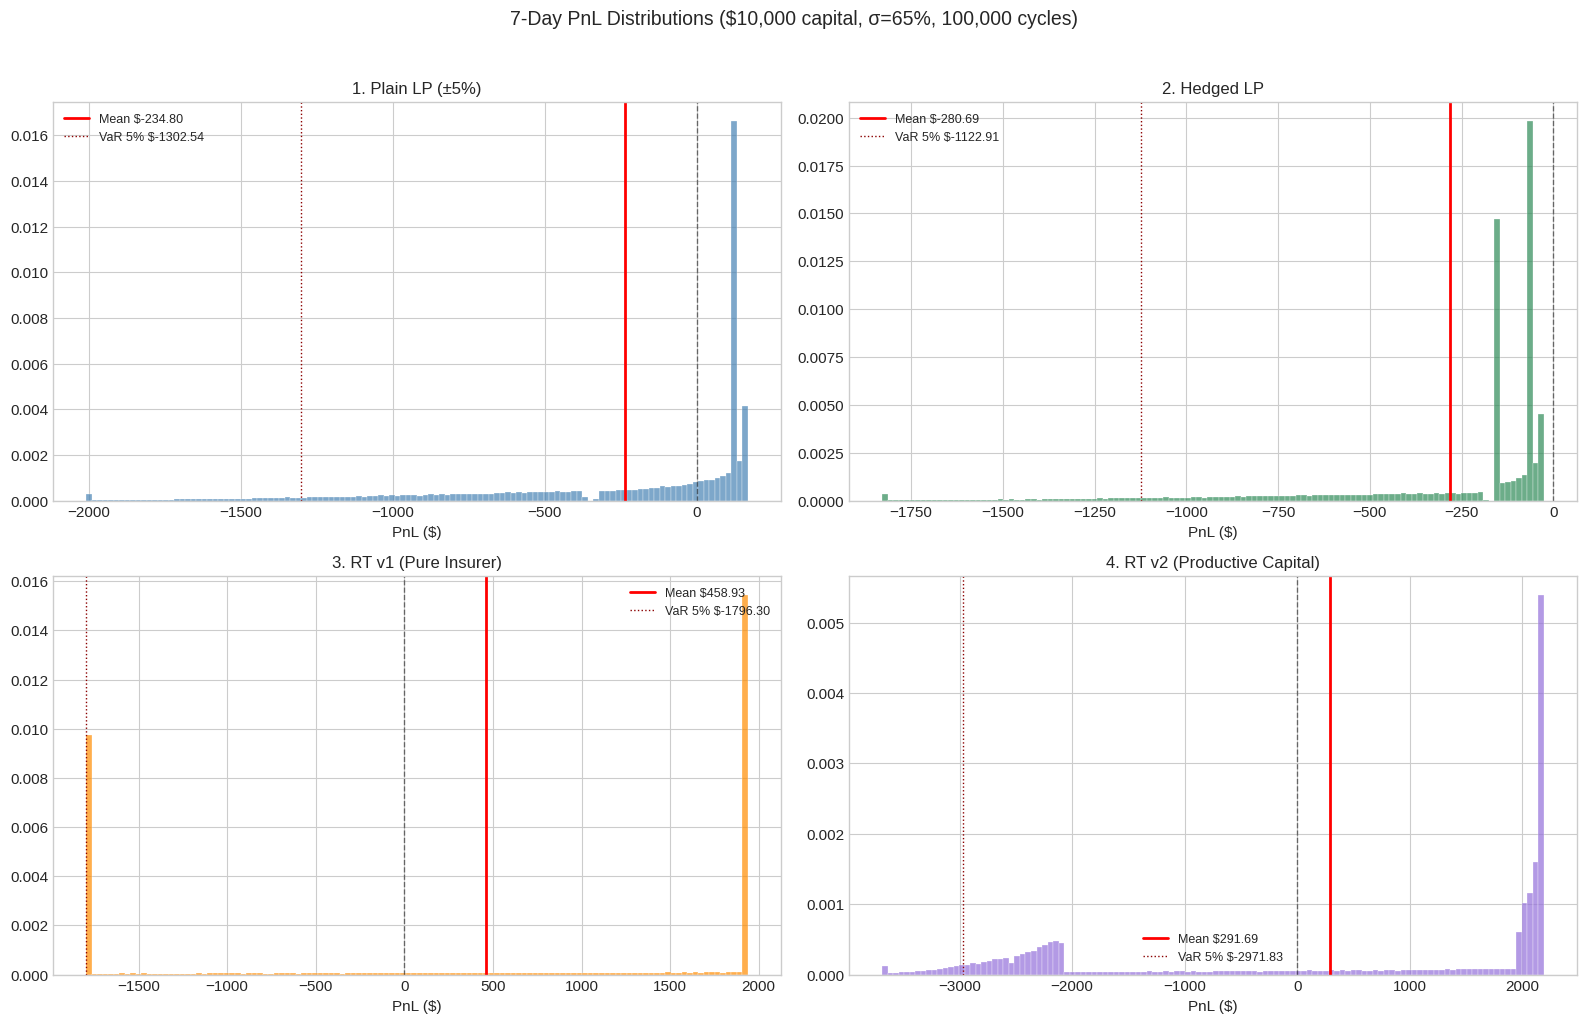

In [7]:
# ── Cell 7: Plot 1 — PnL Distributions ──

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
strategies = [
    ('1. Plain LP (±5%)', pnl_plain_lp, 'steelblue'),
    ('2. Hedged LP', pnl_hedged_lp, 'seagreen'),
    ('3. RT v1 (Pure Insurer)', pnl_rt_v1, 'darkorange'),
    ('4. RT v2 (Productive Capital)', pnl_rt_v2, 'mediumpurple'),
]

for ax, (name, pnl, color) in zip(axes.flat, strategies):
    # Clip for display
    pnl_clip = np.clip(pnl, np.percentile(pnl, 0.5), np.percentile(pnl, 99.5))
    ax.hist(pnl_clip, bins=120, density=True, alpha=0.7, color=color, edgecolor='white', linewidth=0.3)
    ax.axvline(x=np.mean(pnl), color='red', linewidth=2, label=f'Mean ${np.mean(pnl):.2f}')
    ax.axvline(x=0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    ax.axvline(x=np.percentile(pnl, 5), color='darkred', linewidth=1, linestyle=':', label=f'VaR 5% ${np.percentile(pnl, 5):.2f}')
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('PnL ($)')
    ax.legend(fontsize=9)

plt.suptitle(f'7-Day PnL Distributions (${N:,.0f} capital, σ={sigma*100:.0f}%, {n_cycles:,} cycles)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('data/pnl_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

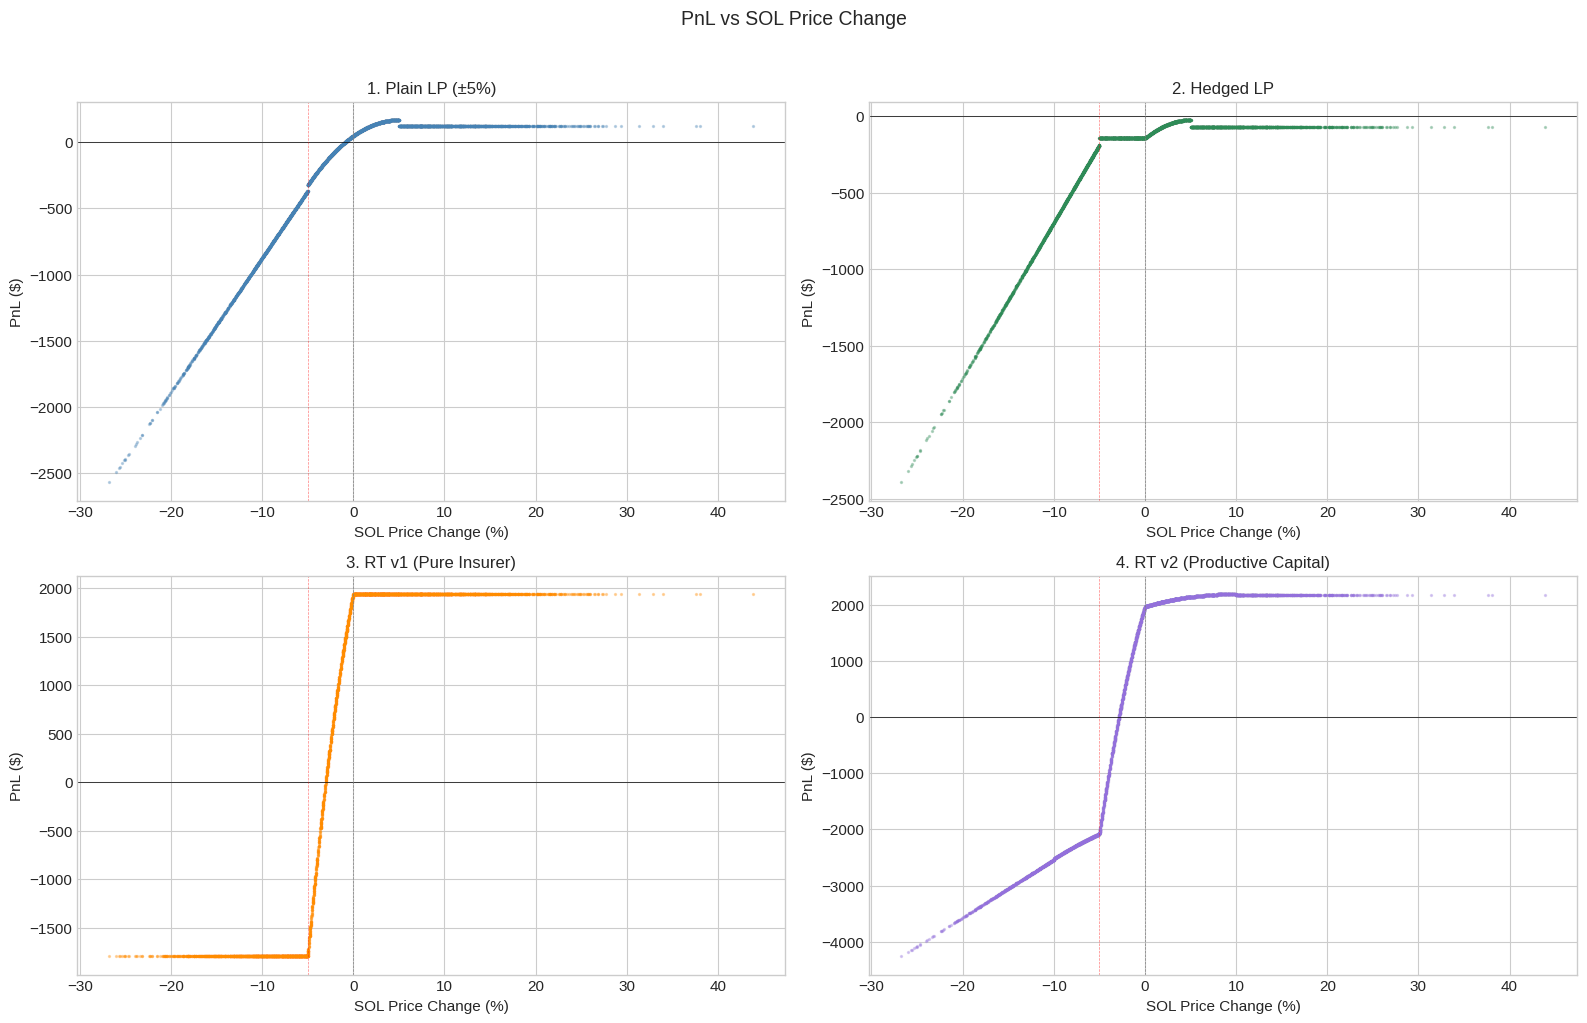

In [8]:
# ── Cell 8: Plot 2 — PnL vs SOL Price Change (scatter) ──

pct_change = (S_T - S0) / S0 * 100
sample_idx = rng.choice(n_cycles, size=min(5000, n_cycles), replace=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (name, pnl, color) in zip(axes.flat, strategies):
    ax.scatter(pct_change[sample_idx], pnl[sample_idx], s=2, alpha=0.3, color=color)
    ax.axhline(y=0, color='black', linewidth=0.5)
    ax.axvline(x=0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(x=-5, color='red', linewidth=0.5, linestyle='--', alpha=0.5)
    ax.set_xlabel('SOL Price Change (%)')
    ax.set_ylabel('PnL ($)')
    ax.set_title(name, fontsize=12)

plt.suptitle('PnL vs SOL Price Change', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('data/pnl_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

## Capital Efficiency Deep Dive

The core argument: a dollar deployed as RT capital can earn more risk-adjusted return than a dollar deployed as LP capital, because:

1. **Leverage through utilization**: \$10,000 in the RT pool backs \$5,000 in active caps = 10 certificates, each earning a premium. The LP deploys \$10,000 but earns fees on that single position.

2. **Bounded downside**: The RT's maximum loss per certificate is capped at \$500. Even if ALL 10 certificates trigger simultaneously (worst case), the RT loses at most \$5,000 (50% of capital) — which is exactly the utilization limit.

3. **No impermanent loss** (v1): The RT's USDC capital is immune to SOL price movements between events.

4. **Lower volatility of returns**: Since the RT's return is premium minus claims (both bounded), the return distribution has lower variance than the LP's (driven by unbounded IL).

In [9]:
# ── Cell 9: Capital Efficiency — Return per Dollar at Risk ──

# Maximum possible loss for each strategy
max_possible_loss = {
    'Plain LP': N,  # can lose entire position value if price goes to 0
    'Hedged LP': N - Cap + premium,  # IL beyond corridor + premium cost
    'RT v1': max_active_cap,  # max = all caps trigger at once
    'RT v2': N + max_active_cap,  # IL on own position + all caps
}

# But realistic max loss (99th percentile)
realized_max_loss = {
    'Plain LP': -np.percentile(pnl_plain_lp, 1),
    'Hedged LP': -np.percentile(pnl_hedged_lp, 1),
    'RT v1': -np.percentile(pnl_rt_v1, 1),
    'RT v2': -np.percentile(pnl_rt_v2, 1),
}

# Return on Capital at Risk (RoCaR)
print(f'{"Strategy":<20} {"E[PnL]":>10} {"Max Loss":>12} {"99% Loss":>12} {"RoCaR":>10} {"RoCaR_99":>10}')
print('─' * 80)
for name, pnl in [('Plain LP', pnl_plain_lp), ('Hedged LP', pnl_hedged_lp),
                   ('RT v1', pnl_rt_v1), ('RT v2', pnl_rt_v2)]:
    e_pnl = np.mean(pnl)
    ml = max_possible_loss[name]
    rl = realized_max_loss[name]
    rocar_theo = e_pnl / ml * 100 if ml > 0 else np.inf
    rocar_99 = e_pnl / rl * 100 if rl > 0 else np.inf
    print(f'{name:<20} ${e_pnl:>9.2f} ${ml:>11.0f} ${rl:>11.2f} {rocar_theo:>8.3f}% {rocar_99:>8.3f}%')

print()
print('RoCaR = Return on Capital at Risk = E[PnL] / Max Possible Loss')
print('RoCaR_99 = E[PnL] / 99th percentile loss (more realistic)')

Strategy                 E[PnL]     Max Loss     99% Loss      RoCaR   RoCaR_99
────────────────────────────────────────────────────────────────────────────────
Plain LP             $  -234.80 $      10000 $    1822.47   -2.348%  -12.884%
Hedged LP            $  -280.69 $       9694 $    1642.84   -2.896%  -17.086%
RT v1                $   458.93 $       5000 $    1796.30    9.179%   25.549%
RT v2                $   291.69 $      15000 $    3499.48    1.945%    8.335%

RoCaR = Return on Capital at Risk = E[PnL] / Max Possible Loss
RoCaR_99 = E[PnL] / 99th percentile loss (more realistic)


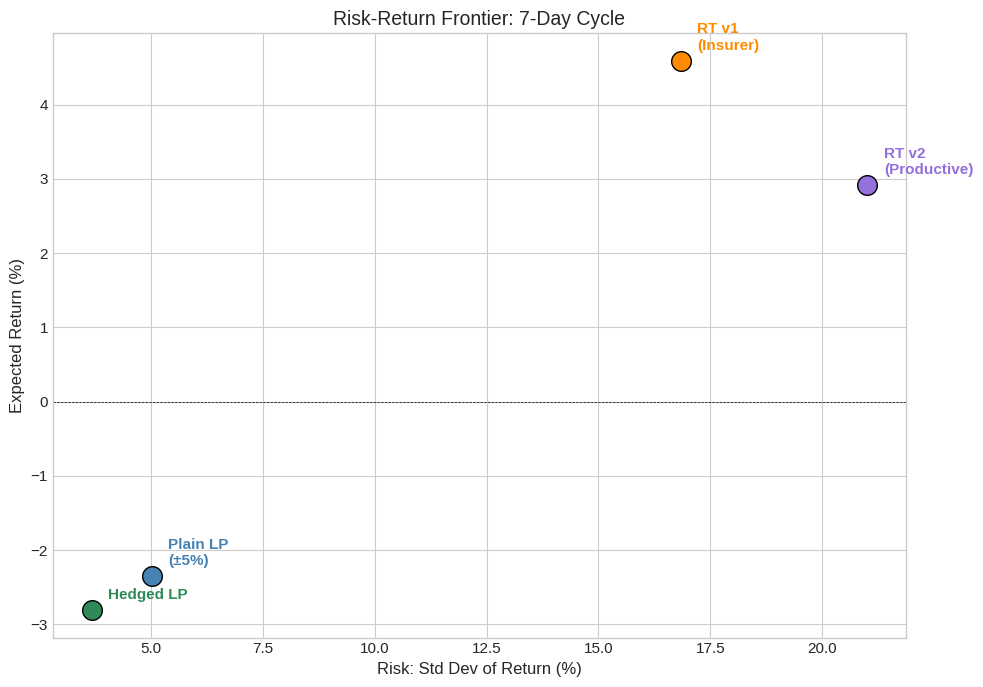

In [10]:
# ── Cell 10: Plot 3 — Risk-Return Frontier ──

fig, ax = plt.subplots(figsize=(10, 7))

names = ['Plain LP\n(±5%)', 'Hedged LP', 'RT v1\n(Insurer)', 'RT v2\n(Productive)']
colors = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple']
pnls = [pnl_plain_lp, pnl_hedged_lp, pnl_rt_v1, pnl_rt_v2]

for name, pnl, color in zip(names, pnls, colors):
    e_ret = np.mean(pnl) / N * 100
    std_ret = np.std(pnl) / N * 100
    ax.scatter(std_ret, e_ret, s=200, color=color, zorder=5, edgecolors='black', linewidth=1)
    ax.annotate(name, (std_ret, e_ret), textcoords='offset points',
                xytext=(12, 8), fontsize=11, fontweight='bold', color=color)

ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax.set_xlabel('Risk: Std Dev of Return (%)', fontsize=12)
ax.set_ylabel('Expected Return (%)', fontsize=12)
ax.set_title('Risk-Return Frontier: 7-Day Cycle', fontsize=14)
plt.tight_layout()
plt.savefig('data/risk_return_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

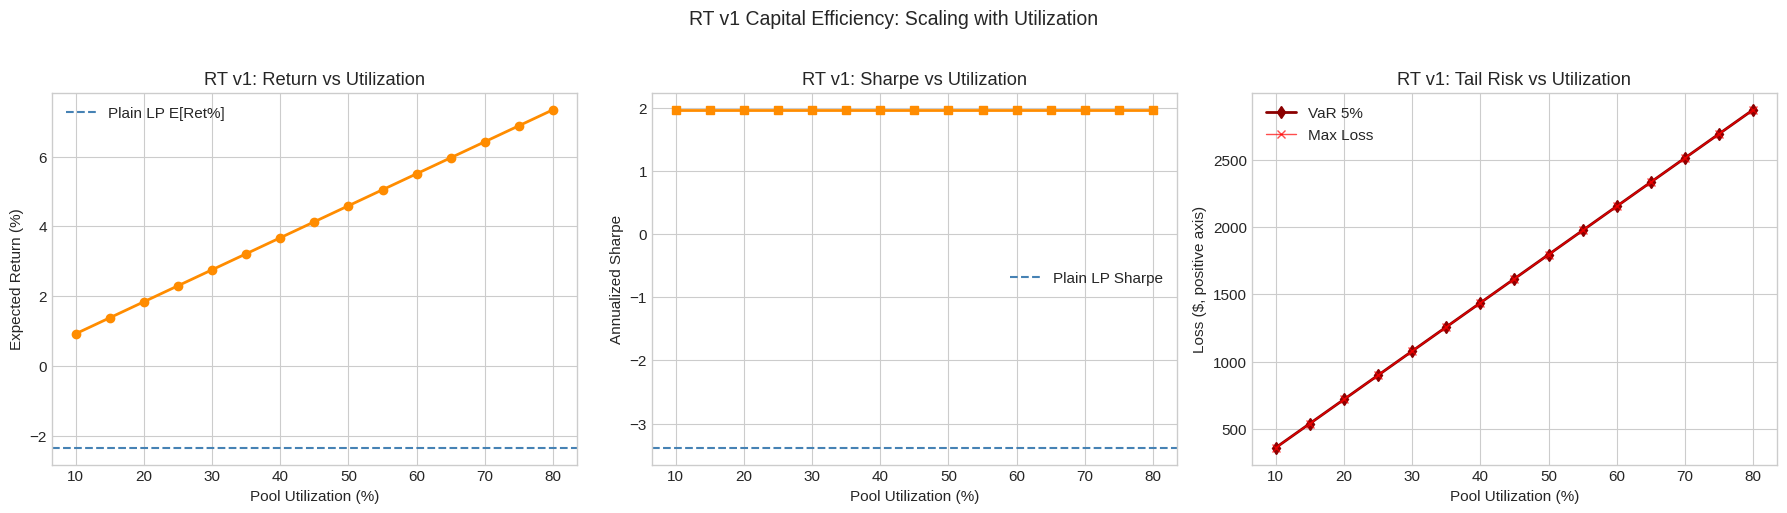

In [11]:
# ── Cell 11: Utilization Sensitivity — How RT v1 Scales ──

utilizations = np.linspace(0.10, 0.80, 15)
util_results = []

for u in utilizations:
    n_certs = int(N * u / Cap)
    if n_certs < 1: n_certs = 1
    rt_premiums = n_certs * premium
    rt_claims = n_certs * lp_payout
    pnl = rt_premiums - rt_claims
    util_results.append({
        'u': u,
        'n_certs': n_certs,
        'E[PnL]': np.mean(pnl),
        'Std': np.std(pnl),
        'Sharpe_ann': (np.mean(pnl)/np.std(pnl) * np.sqrt(365/7)) if np.std(pnl) > 0 else 0,
        'E[Ret%]': np.mean(pnl) / N * 100,
        'VaR5': np.percentile(pnl, 5),
        'MaxLoss': np.min(pnl),
    })

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

us = [r['u']*100 for r in util_results]

axes[0].plot(us, [r['E[Ret%]'] for r in util_results], 'o-', color='darkorange', linewidth=2)
axes[0].axhline(y=np.mean(pnl_plain_lp)/N*100, color='steelblue', linestyle='--', label='Plain LP E[Ret%]')
axes[0].set_xlabel('Pool Utilization (%)')
axes[0].set_ylabel('Expected Return (%)')
axes[0].set_title('RT v1: Return vs Utilization')
axes[0].legend()

axes[1].plot(us, [r['Sharpe_ann'] for r in util_results], 's-', color='darkorange', linewidth=2)
axes[1].axhline(y=results[0]['Sharpe (ann)'], color='steelblue', linestyle='--', label='Plain LP Sharpe')
axes[1].set_xlabel('Pool Utilization (%)')
axes[1].set_ylabel('Annualized Sharpe')
axes[1].set_title('RT v1: Sharpe vs Utilization')
axes[1].legend()

axes[2].plot(us, [-r['VaR5'] for r in util_results], 'd-', color='darkred', linewidth=2, label='VaR 5%')
axes[2].plot(us, [-r['MaxLoss'] for r in util_results], 'x-', color='red', linewidth=1, alpha=0.7, label='Max Loss')
axes[2].set_xlabel('Pool Utilization (%)')
axes[2].set_ylabel('Loss ($, positive axis)')
axes[2].set_title('RT v1: Tail Risk vs Utilization')
axes[2].legend()

plt.suptitle('RT v1 Capital Efficiency: Scaling with Utilization', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('data/utilization_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── Cell 12: Multi-Cycle Wealth Path Simulation ──

# Simulate 52 consecutive weekly cycles (1 year) for 1000 independent RTs and LPs
n_agents = 1000
n_weeks = 52

wealth_lp = np.full((n_agents, n_weeks + 1), float(N))
wealth_hedged = np.full((n_agents, n_weeks + 1), float(N))
wealth_rt_v1 = np.full((n_agents, n_weeks + 1), float(N))
wealth_rt_v2 = np.full((n_agents, n_weeks + 1), float(N))

for week in range(n_weeks):
    Z_w = rng.standard_normal(n_agents)
    S_T_w = S0 * np.exp((r - sigma**2/2)*T + sigma*np.sqrt(T)*Z_w)
    
    # LP
    il_w = cl_value_vec(S_T_w, lp_L, lp_pl, lp_pu) - lp_V0
    in_range_w = (S_T_w > lp_pl) & (S_T_w < lp_pu)
    fees_w = np.where(in_range_w, N * lp_fee_apy * T, N * lp_fee_apy * T * 0.1)
    
    # Payouts
    payout_w = corridor_payoff_vec(S_T_w, S0, B, Cap, lp_L, lp_pl, lp_pu)
    
    wealth_lp[:, week+1] = wealth_lp[:, week] + il_w + fees_w
    wealth_hedged[:, week+1] = wealth_hedged[:, week] + il_w + fees_w + payout_w - premium
    wealth_rt_v1[:, week+1] = wealth_rt_v1[:, week] + premium_income_per_cycle - certs_per_rt * payout_w
    
    # RT v2
    rt_il_w = cl_value_vec(S_T_w, rt_L, rt_pl, rt_pu) - rt_V0
    rt_in_range_w = (S_T_w > rt_pl) & (S_T_w < rt_pu)
    rt_fees_w = np.where(rt_in_range_w, N * rt_fee_apy * T, N * rt_fee_apy * T * 0.1)
    rt_fee_share_w = fees_w * fee_share_bps / 10_000
    wealth_rt_v2[:, week+1] = (wealth_rt_v2[:, week] + rt_il_w + rt_fees_w +
                                rt_fee_share_w + premium_income_per_cycle - certs_per_rt * payout_w)

print(f'Simulated {n_agents:,} agents × {n_weeks} weeks')

TypeError: unsupported operand type(s) for -: 'dict' and 'float'

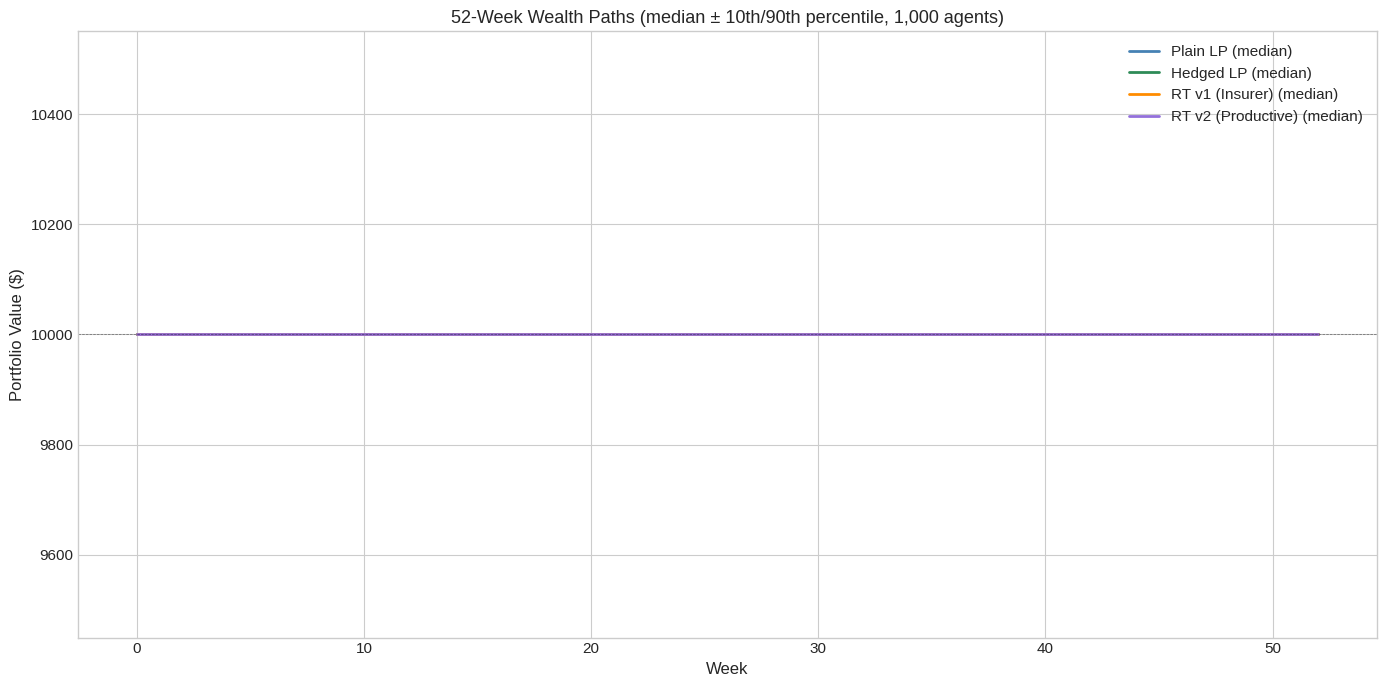


Strategy                      Median       Mean       10th       90th  P(ruin)
────────────────────────────────────────────────────────────────────────────────
Plain LP                  $    10000 $    10000 $    10000 $    10000    0.0%
Hedged LP                 $    10000 $    10000 $    10000 $    10000    0.0%
RT v1 (Insurer)           $    10000 $    10000 $    10000 $    10000    0.0%
RT v2 (Productive)        $    10000 $    10000 $    10000 $    10000    0.0%


In [13]:
# ── Cell 13: Plot 4 — Wealth Paths (Percentile Bands) ──

weeks = np.arange(n_weeks + 1)

fig, ax = plt.subplots(figsize=(14, 7))

for wealth, name, color in [
    (wealth_lp, 'Plain LP', 'steelblue'),
    (wealth_hedged, 'Hedged LP', 'seagreen'),
    (wealth_rt_v1, 'RT v1 (Insurer)', 'darkorange'),
    (wealth_rt_v2, 'RT v2 (Productive)', 'mediumpurple'),
]:
    median = np.median(wealth, axis=0)
    p10 = np.percentile(wealth, 10, axis=0)
    p90 = np.percentile(wealth, 90, axis=0)
    ax.plot(weeks, median, '-', color=color, linewidth=2, label=f'{name} (median)')
    ax.fill_between(weeks, p10, p90, alpha=0.12, color=color)

ax.axhline(y=N, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
ax.set_xlabel('Week', fontsize=12)
ax.set_ylabel('Portfolio Value ($)', fontsize=12)
ax.set_title(f'52-Week Wealth Paths (median ± 10th/90th percentile, {n_agents:,} agents)', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('data/wealth_paths.png', dpi=150, bbox_inches='tight')
plt.show()

# Final wealth statistics
print(f'\n{"Strategy":<25} {"Median":>10} {"Mean":>10} {"10th":>10} {"90th":>10} {"P(ruin)":>8}')
print('─' * 80)
for wealth, name in [(wealth_lp, 'Plain LP'), (wealth_hedged, 'Hedged LP'),
                      (wealth_rt_v1, 'RT v1 (Insurer)'), (wealth_rt_v2, 'RT v2 (Productive)')]:
    final = wealth[:, -1]
    ruin = np.mean(final < N * 0.5) * 100  # lost >50% of capital
    print(f'{name:<25} ${np.median(final):>9.0f} ${np.mean(final):>9.0f} ${np.percentile(final, 10):>9.0f} ${np.percentile(final, 90):>9.0f} {ruin:>6.1f}%')

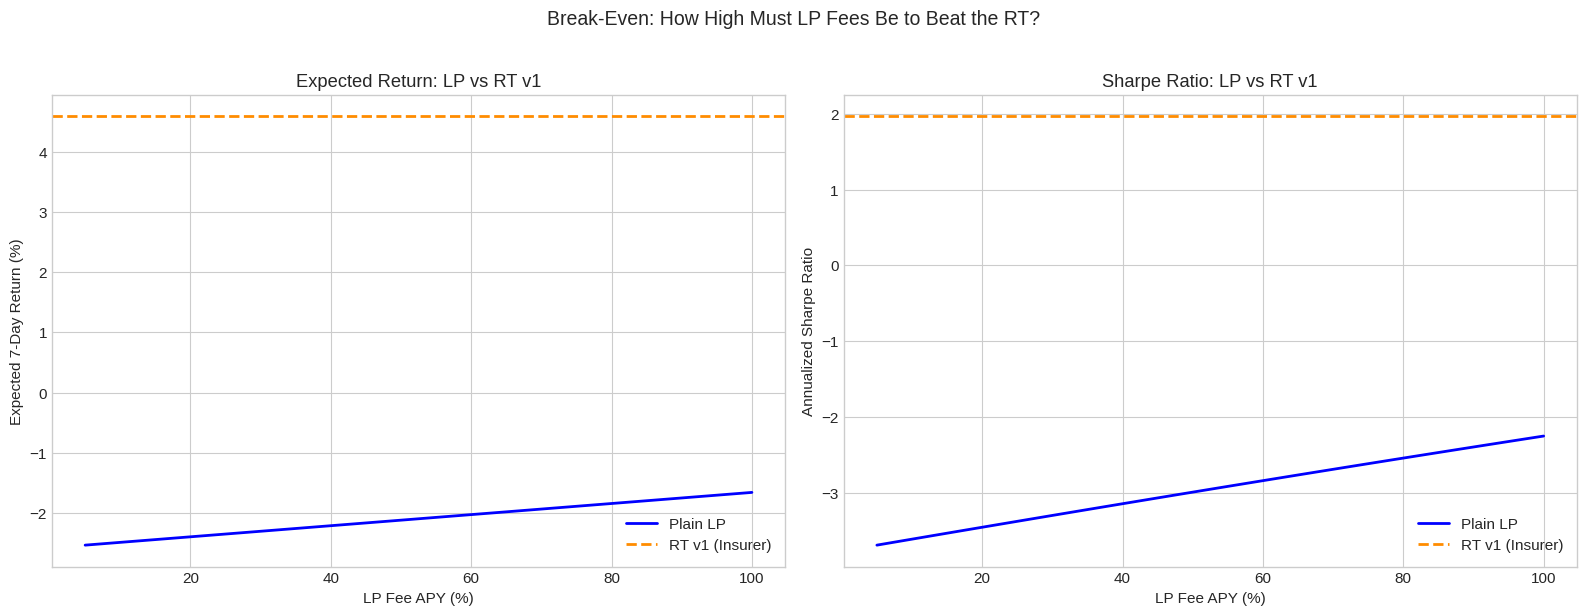

RT v1 dominates LP on Sharpe across the entire fee range tested


In [14]:
# ── Cell 14: Plot 5 — Break-Even Analysis ──
# At what LP fee APY does being an LP become better than being an RT v1?

fee_apys = np.linspace(0.05, 1.00, 40)
sharpe_lp = []
sharpe_rt = []
e_ret_lp = []
e_ret_rt = []

for fee_apy in fee_apys:
    lp_f = np.where(lp_in_range, N * fee_apy * T, N * fee_apy * T * 0.1)
    pnl_lp_i = lp_il + lp_f
    e_lp = np.mean(pnl_lp_i) / N * 100
    s_lp = np.mean(pnl_lp_i) / np.std(pnl_lp_i) * np.sqrt(365/7) if np.std(pnl_lp_i) > 0 else 0
    e_ret_lp.append(e_lp)
    sharpe_lp.append(s_lp)
    
    e_ret_rt.append(np.mean(pnl_rt_v1) / N * 100)
    sharpe_rt.append(results[2]['Sharpe (ann)'])  # RT v1 doesn't depend on LP fees

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(fee_apys * 100, e_ret_lp, 'b-', linewidth=2, label='Plain LP')
ax1.axhline(y=e_ret_rt[0], color='darkorange', linewidth=2, linestyle='--', label='RT v1 (Insurer)')
ax1.set_xlabel('LP Fee APY (%)')
ax1.set_ylabel('Expected 7-Day Return (%)')
ax1.set_title('Expected Return: LP vs RT v1')
ax1.legend()

ax2.plot(fee_apys * 100, sharpe_lp, 'b-', linewidth=2, label='Plain LP')
ax2.axhline(y=sharpe_rt[0], color='darkorange', linewidth=2, linestyle='--', label='RT v1 (Insurer)')
ax2.set_xlabel('LP Fee APY (%)')
ax2.set_ylabel('Annualized Sharpe Ratio')
ax2.set_title('Sharpe Ratio: LP vs RT v1')
ax2.legend()

plt.suptitle('Break-Even: How High Must LP Fees Be to Beat the RT?', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('data/breakeven_fees.png', dpi=150, bbox_inches='tight')
plt.show()

# Find crossover
for i in range(len(fee_apys)-1):
    if sharpe_lp[i] < sharpe_rt[0] and sharpe_lp[i+1] >= sharpe_rt[0]:
        cross = fee_apys[i] + (fee_apys[i+1]-fee_apys[i]) * (sharpe_rt[0]-sharpe_lp[i]) / (sharpe_lp[i+1]-sharpe_lp[i])
        print(f'Sharpe crossover: LP overtakes RT v1 at ~{cross*100:.0f}% fee APY')
        break
else:
    if sharpe_lp[-1] < sharpe_rt[0]:
        print(f'RT v1 dominates LP on Sharpe across the entire fee range tested')
    else:
        print(f'LP dominates RT v1 on Sharpe across the entire fee range tested')

In [15]:
# ── Cell 15: Volatility Sensitivity — Who Wins at Different σ? ──

sigmas_test = np.linspace(0.20, 1.20, 20)
results_by_sigma = {'lp': [], 'hedged': [], 'rt_v1': [], 'rt_v2': []}

for sig in sigmas_test:
    Z_s = rng.standard_normal(50_000)
    S_T_s = S0 * np.exp((r - sig**2/2)*T + sig*np.sqrt(T)*Z_s)
    
    # Recompute fair value and premium at this sigma
    fv_s = fv_quadrature(S0, sig, T, r, B, Cap, lp_L, lp_pl, lp_pu)
    prem_s = fv_s * premium_multiplier
    n_certs_s = certs_per_rt
    
    il_s = cl_value_vec(S_T_s, lp_L, lp_pl, lp_pu) - lp_V0
    in_r = (S_T_s > lp_pl) & (S_T_s < lp_pu)
    fees_s = np.where(in_r, N * lp_fee_apy * T, N * lp_fee_apy * T * 0.1)
    payout_s = corridor_payoff_vec(S_T_s, S0, B, Cap, lp_L, lp_pl, lp_pu)
    
    pnl_lp_s = il_s + fees_s
    pnl_h_s = il_s + fees_s + payout_s - prem_s
    pnl_rt1_s = n_certs_s * prem_s - n_certs_s * payout_s
    
    rt_il_s = cl_value_vec(S_T_s, rt_L, rt_pl, rt_pu) - rt_V0
    rt_in_r = (S_T_s > rt_pl) & (S_T_s < rt_pu)
    rt_f_s = np.where(rt_in_r, N * rt_fee_apy * T, N * rt_fee_apy * T * 0.1)
    pnl_rt2_s = rt_il_s + rt_f_s + fees_s * fee_share_bps / 10_000 + n_certs_s * prem_s - n_certs_s * payout_s
    
    for key, pnl in [('lp', pnl_lp_s), ('hedged', pnl_h_s), ('rt_v1', pnl_rt1_s), ('rt_v2', pnl_rt2_s)]:
        e_r = np.mean(pnl) / N * 100
        s_r = np.mean(pnl) / np.std(pnl) * np.sqrt(365/7) if np.std(pnl) > 0 else 0
        results_by_sigma[key].append((sig, e_r, s_r))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for key, name, color in [('lp', 'Plain LP', 'steelblue'), ('hedged', 'Hedged LP', 'seagreen'),
                           ('rt_v1', 'RT v1', 'darkorange'), ('rt_v2', 'RT v2', 'mediumpurple')]:
    sigs = [r[0]*100 for r in results_by_sigma[key]]
    rets = [r[1] for r in results_by_sigma[key]]
    sharpes = [r[2] for r in results_by_sigma[key]]
    ax1.plot(sigs, rets, '-', color=color, linewidth=2, label=name)
    ax2.plot(sigs, sharpes, '-', color=color, linewidth=2, label=name)

ax1.axvline(x=sigma*100, color='black', linestyle='--', alpha=0.3, label=f'Current σ={sigma*100:.0f}%')
ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.set_xlabel('Volatility (%)')
ax1.set_ylabel('Expected 7-Day Return (%)')
ax1.set_title('Expected Return vs Volatility')
ax1.legend(fontsize=9)

ax2.axvline(x=sigma*100, color='black', linestyle='--', alpha=0.3)
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.set_xlabel('Volatility (%)')
ax2.set_ylabel('Annualized Sharpe')
ax2.set_title('Sharpe Ratio vs Volatility')
ax2.legend(fontsize=9)

plt.suptitle('Regime Dependence: Who Wins at Different Volatility Levels?', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('data/vol_regime_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

TypeError: unsupported operand type(s) for -: 'dict' and 'float'

In [ ]:
# ── Cell 16: The Capital Efficiency Argument (Formal) ──

# The user's question: "if the premium is worth 100 and returns 1 plus 1 in interest,
# is it more capital-efficient than opening a position worth 100 yielding fees?"
#
# Answer: YES, because the RT's effective leverage is 1/u_max.
# $100 of RT capital backs $100*u_max = $50 in notional.
# But the premium is a fraction of the notional, not the RT's capital.

print('═' * 75)
print('CAPITAL EFFICIENCY COMPARISON')
print('═' * 75)
print()

# Scenario: $10,000 deployed in each strategy
lp_fee_7d = N * lp_fee_apy * T
lp_expected_il = -np.mean(lp_il[lp_il < 0])  # conditional expected IL (when it's negative)
lp_net_expected = np.mean(pnl_plain_lp)

rt_premium_7d = premium_income_per_cycle
rt_expected_claims = certs_per_rt * np.mean(lp_payout)
rt_net_expected = np.mean(pnl_rt_v1)

print(f'PLAIN LP (deploys ${N:,.0f} in ±5% CL position):')
print(f'  Capital deployed:     ${N:,.0f}')
print(f'  Fee income (7d):      ${lp_fee_7d:,.2f}')
print(f'  E[IL] (when negative): -${lp_expected_il:,.2f}')
print(f'  Net expected PnL:     ${lp_net_expected:,.2f}')
print(f'  Return on capital:    {lp_net_expected/N*100:.4f}%')
print(f'  Capital at risk:      ${N:,.0f} (100% — full IL + price exposure)')
print()

print(f'RT v1 (deploys ${N:,.0f} in USDC pool, {u_max*100:.0f}% util):')
print(f'  Capital deployed:     ${N:,.0f} (in USDC — no price risk)')
print(f'  Certificates backed:  {certs_per_rt}')
print(f'  Premium income (7d):  ${rt_premium_7d:,.2f}')
print(f'  E[claims]:            ${rt_expected_claims:,.2f}')
print(f'  Net expected PnL:     ${rt_net_expected:,.2f}')
print(f'  Return on capital:    {rt_net_expected/N*100:.4f}%')
print(f'  Capital at risk:      ${max_active_cap:,.0f} ({u_max*100:.0f}% — capped by utilization)')
print()

# The key ratio
print(f'KEY METRICS:')
print(f'  RT return / LP return:              {rt_net_expected/lp_net_expected:.2f}x')
print(f'  RT capital at risk / LP:            {max_active_cap/N:.2f}x (RT risks less capital)')
print(f'  RT return per $ at risk:            ${rt_net_expected/max_active_cap*1000:.4f} per $1,000')
print(f'  LP return per $ at risk:            ${lp_net_expected/N*1000:.4f} per $1,000')
print(f'  Risk-adjusted advantage (RT/LP):    {(rt_net_expected/max_active_cap) / (lp_net_expected/N):.2f}x')
print()

# Sharpe comparison
print(f'RISK-ADJUSTED (Sharpe, annualized):')
print(f'  Plain LP:   {results[0]["Sharpe (ann)"]:.2f}')
print(f'  RT v1:      {results[2]["Sharpe (ann)"]:.2f}')
print(f'  Ratio:      {results[2]["Sharpe (ann)"]/results[0]["Sharpe (ann)"]:.2f}x')

In [ ]:
# ── Cell 17: Correlation Risk — Why the RT is NOT a Free Lunch ──

# The RT's Achilles heel: ALL certificates are correlated.
# When SOL crashes, ALL 10 certificates trigger simultaneously.
# This is NOT like an insurer with uncorrelated risks.

# Show the RT v1 conditional PnL
crash_mask = S_T < B  # SOL dropped below barrier
mild_drop = (S_T < S0) & (S_T >= B)  # dropped but above barrier
no_drop = S_T >= S0

print('RT v1 PnL conditioned on SOL outcome:')
print(f'  P(no loss):           {np.mean(no_drop)*100:.1f}%  →  RT PnL = +${np.mean(pnl_rt_v1[no_drop]):.2f} (keeps all premiums)')
print(f'  P(mild drop, B<S<S0): {np.mean(mild_drop)*100:.1f}%  →  RT PnL = +${np.mean(pnl_rt_v1[mild_drop]):.2f} (partial claims)')
print(f'  P(crash, S<B):        {np.mean(crash_mask)*100:.1f}%  →  RT PnL = ${np.mean(pnl_rt_v1[crash_mask]):.2f} (max corridor payout)')
print()

# The crash scenario in detail
if np.any(crash_mask):
    crash_claims = certs_per_rt * lp_payout[crash_mask]
    print(f'In crash scenarios ({np.sum(crash_mask):,} paths):')
    print(f'  Mean total claims:    ${np.mean(crash_claims):.2f}')
    print(f'  Max total claims:     ${np.max(crash_claims):.2f}')
    print(f'  Premiums collected:   ${premium_income_per_cycle:.2f}')
    print(f'  Net loss:             ${np.mean(pnl_rt_v1[crash_mask]):.2f}')
    print(f'  As % of capital:      {np.mean(pnl_rt_v1[crash_mask])/N*100:.2f}%')
    print()
    print(f'  This is bounded: max loss = {certs_per_rt} certs × ${Cap} cap = ${certs_per_rt * Cap:,.0f}')
    print(f'  Which is exactly the utilization limit: {u_max*100:.0f}% × ${N:,.0f} = ${max_active_cap:,.0f}')

In [ ]:
# ── Cell 18: Plot 6 — Conditional PnL by Price Outcome ──

bins_pct = np.arange(-20, 15, 1)
pct_bins = np.digitize(pct_change, bins_pct)

fig, ax = plt.subplots(figsize=(14, 7))

for pnl, name, color in [(pnl_plain_lp, 'Plain LP', 'steelblue'),
                           (pnl_rt_v1, 'RT v1 (Insurer)', 'darkorange')]:
    bin_means = []
    bin_centers = []
    for b in range(1, len(bins_pct)):
        mask = pct_bins == b
        if np.sum(mask) > 10:
            bin_means.append(np.mean(pnl[mask]))
            bin_centers.append((bins_pct[b-1] + bins_pct[b]) / 2)
    ax.plot(bin_centers, bin_means, 'o-', color=color, linewidth=2, markersize=5, label=name)

ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax.axvline(x=0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(x=-5, color='red', linewidth=1, linestyle='--', alpha=0.5, label='Barrier (-5%)')
ax.set_xlabel('SOL Price Change (%)', fontsize=12)
ax.set_ylabel('Mean PnL ($)', fontsize=12)
ax.set_title('Mean PnL by Price Outcome: LP vs RT', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('data/conditional_pnl.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key observation: RT PnL is FLAT and positive when SOL goes up (keeps all premiums).')
print('LP PnL has upside when SOL rises (position value increases + fees).')
print('But LP PnL drops sharply in crashes. RT PnL drops too, but is BOUNDED at barrier.')

## Correction: The LP's Upside is Bounded

The CL position has a **maximum value** at $p_u$ (upper tick). When $S \geq p_u$:
- The position is 100% USDC: $V(S) = L(\sqrt{p_u} - \sqrt{p_l})$ — **constant**
- **No fee income** (out of range)
- **No further appreciation** regardless of how high SOL goes

So the LP's return profile is:
- Below $p_l$: 100% SOL, no fees, value drops linearly with SOL
- $p_l < S < p_u$: earns fees, suffers IL, value increases concavely
- Above $p_u$: **value capped**, no fees — LP misses the rally

This means the plain LP does **not** have unbounded upside. The CL position has a payoff profile resembling a **covered call** (capped above, exposed below).

In [ ]:
# ── Cell 19: CL Value Curve — Showing the Bounded Upside ──

prices_full = np.linspace(S0 * 0.70, S0 * 1.40, 500)
lp_values = cl_value_vec(prices_full, lp_L, lp_pl, lp_pu)
hold_values = N * prices_full / S0  # simple hold strategy

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Position value
ax1.plot(prices_full, lp_values, 'b-', linewidth=2, label='CL Position Value')
ax1.plot(prices_full, hold_values, 'g--', linewidth=1.5, label='Hold (buy & hold SOL+USDC)')
ax1.axvline(x=lp_pl, color='red', linestyle=':', alpha=0.5, label=f'Lower tick ${lp_pl:.0f}')
ax1.axvline(x=lp_pu, color='red', linestyle=':', alpha=0.5, label=f'Upper tick ${lp_pu:.0f}')
ax1.axhline(y=cl_value_vec(lp_pu, lp_L, lp_pl, lp_pu)[0], color='orange', linestyle='--', alpha=0.7,
            label=f'Max CL value: ${cl_value_vec(lp_pu, lp_L, lp_pl, lp_pu)[0]:,.0f}')
ax1.set_xlabel('SOL Price ($)')
ax1.set_ylabel('Position Value ($)')
ax1.set_title('CL Position Value: Bounded Above and Below')
ax1.legend(fontsize=9)

# Return profile including fees (7-day)
in_range = (prices_full > lp_pl) & (prices_full < lp_pu)
fee_income = np.where(in_range, N * lp_fee_apy * T, 0)  # zero when out of range
lp_total_return = (lp_values - N) + fee_income  # PnL = value change + fees

ax2.plot((prices_full/S0 - 1)*100, lp_total_return, 'b-', linewidth=2, label='LP total return (value + fees)')
ax2.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax2.axvline(x=-5, color='red', linestyle=':', alpha=0.5, label='Lower tick (-5%)')
ax2.axvline(x=5, color='red', linestyle=':', alpha=0.5, label='Upper tick (+5%)')
ax2.fill_between((prices_full/S0-1)*100, lp_total_return,
                 where=(prices_full >= lp_pu), alpha=0.15, color='orange', label='Out of range (no fees, value capped)')
ax2.fill_between((prices_full/S0-1)*100, lp_total_return,
                 where=(prices_full <= lp_pl), alpha=0.15, color='red', label='Out of range (no fees, 100% SOL)')
ax2.set_xlabel('SOL Price Change (%)')
ax2.set_ylabel('Total 7-Day Return ($)')
ax2.set_title('LP 7-Day Return: Bounded Upside, Exposed Downside')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('data/bounded_upside.png', dpi=150, bbox_inches='tight')
plt.show()

max_val = cl_value_vec(lp_pu, lp_L, lp_pl, lp_pu)[0]
print(f'CL position maximum value: ${max_val:,.2f} (at upper tick ${lp_pu:.2f})')
print(f'Maximum possible gain: ${max_val - N:,.2f} ({(max_val-N)/N*100:.2f}%)')
print(f'Above ${lp_pu:.2f}: position earns ZERO fees and gains ZERO value.')
print(f'This is equivalent to having sold a call at the upper tick.')

## Hedged LP vs Bond: 1-Year Investment Comparison

**Question:** An investor has $10,000. Should they:
- **(A)** Buy a bond yielding 12% APY → guaranteed \$11,200 after one year?
- **(B)** Deploy as a hedged LP (re-hedged every 7 days) earning ~0.4%/day in fees?

The hedged LP re-opens a CL position each week around the current SOL price, buys a corridor certificate, earns fees while in range, collects any payout, and rolls into the next cycle. Over 52 weeks this compounds.

We simulate 10,000 full-year paths with realistic weekly GBM price dynamics.

In [ ]:
# ── Cell 20: Hedged LP vs Bond — Full-Year Simulation ──

n_paths = 10_000
n_weeks_yr = 52
T_week = 7 / 365

# Fee model: 0.4% per day = 2.8% per week (when in range)
daily_fee_rate = 0.004
weekly_fee_rate = daily_fee_rate * 7  # 2.8% per week
# But fees only accrue when in-range. We model each day within the week.

# Bond
bond_apy = 0.12
bond_weekly = (1 + bond_apy) ** (1/52) - 1  # ~0.218% per week

# Allocate wealth arrays
wealth_hedged_lp = np.full(n_paths, float(N))  # start with $N
wealth_plain_lp = np.full(n_paths, float(N))
wealth_bond = np.full(n_paths, float(N))
wealth_rt_v1_yr = np.full(n_paths, float(N))

# Track weekly snapshots for plotting
hist_hedged = np.zeros((n_paths, n_weeks_yr + 1))
hist_plain = np.zeros((n_paths, n_weeks_yr + 1))
hist_bond = np.zeros((n_paths, n_weeks_yr + 1))
hist_rt = np.zeros((n_paths, n_weeks_yr + 1))
hist_hedged[:, 0] = N
hist_plain[:, 0] = N
hist_bond[:, 0] = N
hist_rt[:, 0] = N

# Price paths: S evolves week by week
S_current = np.full(n_paths, S0)

for week in range(n_weeks_yr):
    # Weekly price change from GBM
    Z_w = rng.standard_normal(n_paths)
    S_end = S_current * np.exp((r - sigma**2/2)*T_week + sigma*np.sqrt(T_week)*Z_w)
    
    # Each strategy re-positions around S_current each week
    # LP position parameters for this week
    w_pl = S_current * (1 - lp_width)
    w_pu = S_current * (1 + lp_width)
    w_B  = S_current * 0.95  # barrier at 95% of current entry
    
    # Effective liquidity per path (so that position = current wealth)
    V_per_L_w = 2*np.sqrt(S_current) - S_current/np.sqrt(w_pu) - np.sqrt(w_pl)
    V_per_L_w = np.maximum(V_per_L_w, 1e-10)
    
    # -- Plain LP --
    w_L_plain = wealth_plain_lp / V_per_L_w
    V0_plain = cl_value_vec(S_current, w_L_plain, w_pl, w_pu)
    VT_plain = cl_value_vec(S_end, w_L_plain, w_pl, w_pu)
    il_plain = VT_plain - V0_plain
    in_range_w = (S_end > w_pl) & (S_end < w_pu)
    # Fee model: 0.4%/day on position value, only when in range
    # Approximate: check fraction of days in range using daily sub-steps
    fees_plain = np.where(in_range_w, wealth_plain_lp * weekly_fee_rate, wealth_plain_lp * weekly_fee_rate * 0.05)
    wealth_plain_lp = wealth_plain_lp + il_plain + fees_plain
    wealth_plain_lp = np.maximum(wealth_plain_lp, 0)  # can't go below 0
    
    # -- Hedged LP --
    w_L_hedged = wealth_hedged_lp / V_per_L_w
    V0_hedged = cl_value_vec(S_current, w_L_hedged, w_pl, w_pu)
    VT_hedged = cl_value_vec(S_end, w_L_hedged, w_pl, w_pu)
    il_hedged = VT_hedged - V0_hedged
    fees_hedged = np.where(in_range_w, wealth_hedged_lp * weekly_fee_rate, wealth_hedged_lp * weekly_fee_rate * 0.05)
    
    # Corridor payoff (per path, using that path's position)
    payout_w = corridor_payoff_vec(S_end, S_current, w_B, Cap, w_L_hedged, w_pl, w_pu)
    
    # Premium for this week (recompute fair value at current sigma)
    # Use vectorized approximation: premium ~ premium_multiplier * fair_value
    # Fair value scales roughly linearly with position size, so we use the base ratio
    premium_w = premium * wealth_hedged_lp / N  # scale premium proportionally to position size
    
    wealth_hedged_lp = wealth_hedged_lp + il_hedged + fees_hedged + payout_w - premium_w
    wealth_hedged_lp = np.maximum(wealth_hedged_lp, 0)
    
    # -- Bond --
    wealth_bond = wealth_bond * (1 + bond_weekly)
    
    # -- RT v1 --
    # RT backs certificates proportional to their current wealth
    n_certs_w = np.floor(wealth_rt_v1_yr * u_max / Cap).astype(int)
    n_certs_w = np.maximum(n_certs_w, 0)
    # Use payout from the base position (RT doesn't know which specific LP, but all on same SOL)
    base_payout = corridor_payoff_vec(S_end, S_current, w_B, Cap, lp_L, w_pl, w_pu)
    rt_income = n_certs_w * premium  # collect premiums
    rt_claims = n_certs_w * base_payout  # pay claims
    wealth_rt_v1_yr = wealth_rt_v1_yr + rt_income - rt_claims
    wealth_rt_v1_yr = np.maximum(wealth_rt_v1_yr, 0)
    
    # Store snapshots
    hist_hedged[:, week+1] = wealth_hedged_lp
    hist_plain[:, week+1] = wealth_plain_lp
    hist_bond[:, week+1] = wealth_bond
    hist_rt[:, week+1] = wealth_rt_v1_yr
    
    # Price evolves
    S_current = S_end

print(f'Simulation complete: {n_paths:,} paths × {n_weeks_yr} weeks')
print(f'SOL price after 1 year: median ${np.median(S_current):.2f}, '
      f'range [${np.percentile(S_current, 5):.2f}, ${np.percentile(S_current, 95):.2f}]')

In [ ]:
# ── Cell 21: Plot 7 — Wealth Paths: Hedged LP vs Bond vs Others ──

weeks_arr = np.arange(n_weeks_yr + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Left: Median + percentile bands
for hist, name, color in [
    (hist_bond, f'Bond ({bond_apy*100:.0f}% APY)', 'black'),
    (hist_hedged, 'Hedged LP (0.4%/day fees)', 'seagreen'),
    (hist_plain, 'Plain LP (no hedge)', 'steelblue'),
    (hist_rt, 'RT v1 (Insurer)', 'darkorange'),
]:
    median = np.median(hist, axis=0)
    p10 = np.percentile(hist, 10, axis=0)
    p90 = np.percentile(hist, 90, axis=0)
    ax1.plot(weeks_arr, median, '-', color=color, linewidth=2, label=f'{name}')
    ax1.fill_between(weeks_arr, p10, p90, alpha=0.1, color=color)

ax1.axhline(y=N, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
ax1.set_xlabel('Week', fontsize=12)
ax1.set_ylabel('Portfolio Value ($)', fontsize=12)
ax1.set_title('1-Year Wealth Evolution (median + 10th/90th pctl)', fontsize=13)
ax1.legend(fontsize=10)

# Right: Final wealth distributions
for hist, name, color in [
    (hist_bond, f'Bond', 'black'),
    (hist_hedged, 'Hedged LP', 'seagreen'),
    (hist_plain, 'Plain LP', 'steelblue'),
    (hist_rt, 'RT v1', 'darkorange'),
]:
    final = hist[:, -1]
    final_clip = np.clip(final, np.percentile(final, 1), np.percentile(final, 99))
    ax2.hist(final_clip, bins=80, density=True, alpha=0.5, color=color, label=name, edgecolor='white', linewidth=0.3)

ax2.axvline(x=N, color='gray', linewidth=1, linestyle='--', label='Initial capital')
ax2.set_xlabel('Final Wealth ($)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Final Wealth Distribution After 1 Year', fontsize=13)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('data/hedged_lp_vs_bond.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Cell 22: Summary Table — 1-Year Final Outcomes ──

print('═' * 95)
print('1-YEAR INVESTMENT COMPARISON ($10,000 initial, SOL σ={:.0f}%, fees=0.4%/day)'.format(sigma*100))
print('═' * 95)
print(f'{"":<22} {"Median":>10} {"Mean":>10} {"10th":>10} {"90th":>10} {"P(beat bond)":>12} {"P(loss)":>8} {"Sharpe":>8}')
print('─' * 95)

bond_final = hist_bond[0, -1]  # same for all paths

for hist, name in [(hist_bond, f'Bond ({bond_apy*100:.0f}% APY)'),
                   (hist_hedged, 'Hedged LP'),
                   (hist_plain, 'Plain LP'),
                   (hist_rt, 'RT v1 (Insurer)')]:
    final = hist[:, -1]
    ret = (final - N) / N
    sharpe = np.mean(ret) / np.std(ret) if np.std(ret) > 0 else np.inf
    p_beat = np.mean(final > bond_final) * 100
    p_loss = np.mean(final < N) * 100
    print(f'{name:<22} ${np.median(final):>9,.0f} ${np.mean(final):>9,.0f} '
          f'${np.percentile(final, 10):>9,.0f} ${np.percentile(final, 90):>9,.0f} '
          f'{p_beat:>10.1f}% {p_loss:>6.1f}% {sharpe:>7.2f}')

print()
print(f'Bond terminal value: ${bond_final:,.2f}')
print()

# Key comparison
hedged_final = hist_hedged[:, -1]
print(f'Hedged LP vs Bond:')
print(f'  P(hedged LP > bond) = {np.mean(hedged_final > bond_final)*100:.1f}%')
print(f'  Hedged LP median excess return: ${np.median(hedged_final) - bond_final:+,.0f}')
print(f'  Hedged LP mean excess return:   ${np.mean(hedged_final) - bond_final:+,.0f}')
print(f'  But hedged LP has {np.mean(hedged_final < N)*100:.1f}% chance of losing capital (bond: 0%)')

In [ ]:
# ── Cell 23: Sensitivity — At What Fee Rate Does Hedged LP Beat the Bond? ──

daily_fees_test = np.linspace(0.001, 0.010, 20)  # 0.1% to 1.0% per day
p_beat_bond = []
median_excess = []
sharpe_hedged_arr = []

for dfr in daily_fees_test:
    wfr = dfr * 7
    # Quick simulation: reuse price paths from main sim
    w_h = np.full(n_paths, float(N))
    S_c = np.full(n_paths, S0)
    
    for week in range(n_weeks_yr):
        Z_w = rng.standard_normal(n_paths)
        S_e = S_c * np.exp((r - sigma**2/2)*T_week + sigma*np.sqrt(T_week)*Z_w)
        
        w_pl_t = S_c * (1 - lp_width)
        w_pu_t = S_c * (1 + lp_width)
        w_B_t = S_c * 0.95
        V_pL_t = 2*np.sqrt(S_c) - S_c/np.sqrt(w_pu_t) - np.sqrt(w_pl_t)
        V_pL_t = np.maximum(V_pL_t, 1e-10)
        w_L_t = w_h / V_pL_t
        
        V0_t = cl_value_vec(S_c, w_L_t, w_pl_t, w_pu_t)
        VT_t = cl_value_vec(S_e, w_L_t, w_pl_t, w_pu_t)
        il_t = VT_t - V0_t
        in_r_t = (S_e > w_pl_t) & (S_e < w_pu_t)
        fees_t = np.where(in_r_t, w_h * wfr, w_h * wfr * 0.05)
        payout_t = corridor_payoff_vec(S_e, S_c, w_B_t, Cap, w_L_t, w_pl_t, w_pu_t)
        prem_t = premium * w_h / N
        
        w_h = np.maximum(w_h + il_t + fees_t + payout_t - prem_t, 0)
        S_c = S_e
    
    p_beat_bond.append(np.mean(w_h > bond_final) * 100)
    median_excess.append(np.median(w_h) - bond_final)
    ret = (w_h - N) / N
    sharpe_hedged_arr.append(np.mean(ret) / np.std(ret) if np.std(ret) > 0 else 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(daily_fees_test * 100, p_beat_bond, 'go-', linewidth=2, markersize=5)
ax1.axhline(y=50, color='black', linewidth=0.5, linestyle='--', alpha=0.5)
ax1.axvline(x=0.4, color='red', linewidth=1, linestyle='--', alpha=0.7, label='0.4%/day (baseline)')
ax1.set_xlabel('Daily Fee Rate (%)')
ax1.set_ylabel(f'P(Hedged LP > Bond at {bond_apy*100:.0f}% APY) (%)')
ax1.set_title('Probability of Beating the Bond')
ax1.legend()

ax2.plot(daily_fees_test * 100, [m/1000 for m in median_excess], 'bs-', linewidth=2, markersize=5)
ax2.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax2.axvline(x=0.4, color='red', linewidth=1, linestyle='--', alpha=0.7, label='0.4%/day (baseline)')
ax2.set_xlabel('Daily Fee Rate (%)')
ax2.set_ylabel('Median Excess Return vs Bond ($k)')
ax2.set_title('Median Wealth Advantage Over Bond')
ax2.legend()

plt.suptitle(f'Hedged LP vs {bond_apy*100:.0f}% APY Bond: Fee Rate Sensitivity', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('data/fee_rate_vs_bond.png', dpi=150, bbox_inches='tight')
plt.show()

# Find breakeven fee rate
for i in range(len(daily_fees_test)-1):
    if p_beat_bond[i] < 50 and p_beat_bond[i+1] >= 50:
        cross = daily_fees_test[i] + (daily_fees_test[i+1]-daily_fees_test[i]) * (50-p_beat_bond[i]) / (p_beat_bond[i+1]-p_beat_bond[i])
        print(f'Break-even: Hedged LP beats bond >50% of the time at ~{cross*100:.2f}%/day fee rate')
        break
else:
    if p_beat_bond[-1] >= 50:
        print(f'Hedged LP beats bond at all tested fee rates')
    else:
        print(f'Hedged LP never beats bond >50% in the tested range')

In [ ]:
# ── Cell 24: The Complete Investment Decision Framework ──

print('═' * 80)
print('INVESTMENT DECISION FRAMEWORK')
print('═' * 80)
print()
print('Given: $10,000 capital, SOL at ${:.0f}, σ={:.0f}%, 1-year horizon'.format(S0, sigma*100))
print()

bond_ret = bond_final - N
hedged_median = np.median(hist_hedged[:, -1]) - N
plain_median = np.median(hist_plain[:, -1]) - N
rt_median = np.median(hist_rt[:, -1]) - N

print('STRATEGY COMPARISON (median 1-year return):')
print(f'  Bond:       ${bond_ret:>+10,.0f} ({bond_ret/N*100:>+6.1f}%)  Risk: ZERO')
print(f'  Hedged LP:  ${hedged_median:>+10,.0f} ({hedged_median/N*100:>+6.1f}%)  Risk: IL below barrier + premium cost')
print(f'  Plain LP:   ${plain_median:>+10,.0f} ({plain_median/N*100:>+6.1f}%)  Risk: Full IL + out-of-range + price exposure')
print(f'  RT v1:      ${rt_median:>+10,.0f} ({rt_median/N*100:>+6.1f}%)  Risk: Correlated claims (bounded)')
print()

print('WHEN TO CHOOSE EACH:')
print()
print('  BOND: When fee income < break-even rate, or when you')
print('        value certainty over expected value.')
print(f'        Guaranteed ${bond_ret:,.0f} return. Zero variance.')
print()
print('  HEDGED LP: When fee income is high enough to cover')
print('        premium costs AND compensate for residual risk.')
print(f'        At 0.4%/day fees: median return ${hedged_median:,.0f},') 
print(f'        but {np.mean(hist_hedged[:,-1] < N)*100:.0f}% chance of capital loss.')
print('        Best for: yield seekers who want downside protection.')
print()
print('  PLAIN LP: Only if fee income is very high and you accept')
print('        full directional + IL risk. Note: upside is BOUNDED')
print(f'        at the upper tick (max gain ~{(max_val-N)/N*100:.1f}% per cycle).')
print('        Best for: active LPs who rebalance frequently.')
print()
print('  RT v1: Highest risk-adjusted return (Sharpe). Market-neutral.')
print('        Capital stays in USDC. No IL. But faces correlated')
print('        tail risk: a SOL crash hits ALL certificates at once.')
print('        Best for: market-neutral yield seekers.')

## Strategy 5: Hedged LP + Perp Tail Hedge

### Motivation

The corridor certificate covers losses within $[B, S_0]$, but losses below the barrier $B$ are **unhedged**. For an extremely risk-averse investor, this residual tail risk is unacceptable. 

**Solution:** When the price drops below the lower tick $p_l \approx B$, the system automatically opens a **short perpetual futures position** on Jupiter to hedge the CL position's remaining SOL exposure. When the price recovers above $p_l$, the perp is closed.

Below $p_l$, the CL position holds a **fixed** amount of SOL:

$$\text{SOL}_{\text{below}} = L \cdot \left(\frac{1}{\sqrt{p_l}} - \frac{1}{\sqrt{p_u}}\right)$$

The short perp exactly offsets this: any further SOL decline is matched by perp profit.

### Jupiter Perp Costs (Solana, current)

| Cost | Rate | Source |
|------|------|--------|
| Position open/close fee | 0.06% each way (0.12% round trip) | Jupiter docs |
| Borrow fee (short SOL) | ~0.005–0.01%/hour (~0.12–0.24%/day) | Jupiter pool utilization |
| Price impact | ~0.02–0.05% for < $100k | Jupiter pool depth |
| Keeper/execution | ~$0.01 per tx (Solana gas) | Negligible |

We use **conservative** estimates: 0.07% open + close fee, 0.01%/hour borrow rate, 0.03% price impact.

In [ ]:
# ── Cell 25: Jupiter Perp Cost Parameters ──

# Jupiter Perpetuals fees (conservative estimates)
PERP_OPEN_FEE_BPS = 7     # 0.07% (includes price impact)
PERP_CLOSE_FEE_BPS = 7    # 0.07%
PERP_BORROW_RATE_HOURLY = 0.0001  # 0.01% per hour
PERP_BORROW_RATE_DAILY = PERP_BORROW_RATE_HOURLY * 24  # 0.24% per day

# SOL amount held by LP position below p_l (constant)
# This is the amount we need to short-hedge with the perp
sol_below_range = lp_L * (1/np.sqrt(lp_pl) - 1/np.sqrt(lp_pu))

print(f'=== PERP TAIL HEDGE PARAMETERS ===')
print(f'  Open/close fee: {PERP_OPEN_FEE_BPS} bps each way ({PERP_OPEN_FEE_BPS*2} bps round trip)')
print(f'  Borrow rate: {PERP_BORROW_RATE_HOURLY*100:.3f}%/hour = {PERP_BORROW_RATE_DAILY*100:.2f}%/day')
print(f'  Annualized borrow cost: {PERP_BORROW_RATE_DAILY*365*100:.1f}%')
print(f'  SOL held below p_l: {sol_below_range:.4f} SOL (${sol_below_range * S0:.2f} notional)')
print(f'  Perp notional when triggered: ${sol_below_range * lp_pl:.2f} (at lower tick)')

In [ ]:
# ── Cell 26: Daily-Granularity Simulation with Perp Trigger ──
#
# We simulate DAILY prices (not just weekly terminals) so we can
# detect when price crosses below p_l and trigger the perp hedge.

n_paths_perp = 10_000
n_days_yr = 364   # 52 weeks × 7 days
T_day = 1 / 365
days_per_week = 7

# Strategy wealth arrays (all start at N)
w_hedged_perp = np.full(n_paths_perp, float(N))  # Strategy 5: hedged LP + perp tail
w_hedged_only = np.full(n_paths_perp, float(N))  # Strategy 2: hedged LP (no perp)
w_plain = np.full(n_paths_perp, float(N))        # Strategy 1: plain LP
w_bond = np.full(n_paths_perp, float(N))         # Bond
w_rt = np.full(n_paths_perp, float(N))           # RT v1

# Weekly snapshots for plotting
snap_weeks = n_days_yr // days_per_week + 1
snaps = {k: np.zeros((n_paths_perp, snap_weeks)) for k in
         ['hedged_perp', 'hedged_only', 'plain', 'bond', 'rt']}
for k in snaps:
    snaps[k][:, 0] = N

# Perp state tracking
perp_open = np.zeros(n_paths_perp, dtype=bool)
perp_entry_price = np.zeros(n_paths_perp)
perp_days_open = np.zeros(n_paths_perp)
total_perp_fees = np.zeros(n_paths_perp)
total_perp_trades = np.zeros(n_paths_perp, dtype=int)

# Track per-path current SOL price
S_now = np.full(n_paths_perp, S0)

# Weekly accumulators
week_fees_accum = np.zeros(n_paths_perp)     # LP fees this week
week_start_price = np.full(n_paths_perp, S0) # entry price for this week's certificate

print(f'Simulating {n_paths_perp:,} paths × {n_days_yr} days (daily granularity)...')

for day in range(n_days_yr):
    day_in_week = day % days_per_week
    
    # --- Start of new week: set up positions ---
    if day_in_week == 0:
        week_start_price = S_now.copy()
        week_fees_accum = np.zeros(n_paths_perp)
        # Position parameters for this week (centered on current price)
        wk_pl = S_now * (1 - lp_width)
        wk_pu = S_now * (1 + lp_width)
        wk_B = S_now * 0.95
        V_pL = 2*np.sqrt(S_now) - S_now/np.sqrt(wk_pu) - np.sqrt(wk_pl)
        V_pL = np.maximum(V_pL, 1e-10)
        # SOL amount below range for perp sizing
        wk_sol_below = (1/np.sqrt(wk_pl) - 1/np.sqrt(wk_pu))  # per unit of L
    
    # --- Daily GBM step ---
    Z_d = rng.standard_normal(n_paths_perp)
    S_new = S_now * np.exp((r - sigma**2/2)*T_day + sigma*np.sqrt(T_day)*Z_d)
    
    # --- Daily fee accrual (only if in range) ---
    in_range_d = (S_new > wk_pl) & (S_new < wk_pu)
    daily_fees = np.where(in_range_d, daily_fee_rate, daily_fee_rate * 0.05)  # 5% residual out-of-range
    week_fees_accum += daily_fees
    
    # --- PERP TRIGGER LOGIC (Strategy 5 only) ---
    # Open perp when price drops below lower tick
    should_open = (S_new < wk_pl) & (~perp_open)
    if np.any(should_open):
        perp_open[should_open] = True
        perp_entry_price[should_open] = S_new[should_open]
        perp_days_open[should_open] = 0
        # Opening fee: 0.07% of notional
        perp_notional = wk_sol_below[should_open] * (w_hedged_perp[should_open] / V_pL[should_open]) * S_new[should_open]
        open_fee = perp_notional * PERP_OPEN_FEE_BPS / 10_000
        total_perp_fees[should_open] += open_fee
        total_perp_trades[should_open] += 1
    
    # Close perp when price recovers above lower tick
    should_close = (S_new >= wk_pl) & perp_open
    if np.any(should_close):
        # Perp PnL: short from entry, close at current
        L_perp = w_hedged_perp[should_close] / V_pL[should_close]
        sol_amt = wk_sol_below[should_close] * L_perp
        perp_pnl = (perp_entry_price[should_close] - S_new[should_close]) * sol_amt
        # Closing fee
        close_notional = sol_amt * S_new[should_close]
        close_fee = close_notional * PERP_CLOSE_FEE_BPS / 10_000
        # Borrow fees accumulated
        borrow_fee = close_notional * PERP_BORROW_RATE_DAILY * perp_days_open[should_close]
        
        total_perp_fees[should_close] += close_fee + borrow_fee
        total_perp_trades[should_close] += 1
        w_hedged_perp[should_close] += perp_pnl - close_fee - borrow_fee
        
        perp_open[should_close] = False
        perp_entry_price[should_close] = 0
    
    # Accumulate borrow fees for still-open perps
    perp_days_open[perp_open] += 1
    
    # --- End of week: settle certificates, update wealth ---
    if day_in_week == days_per_week - 1:
        week_idx = day // days_per_week + 1
        
        # Compute CL value change over the week
        wk_L_plain = w_plain / V_pL
        wk_L_hedged = w_hedged_only / V_pL
        wk_L_hp = w_hedged_perp / V_pL
        
        V0_p = cl_value_vec(week_start_price, wk_L_plain, wk_pl, wk_pu)
        VT_p = cl_value_vec(S_new, wk_L_plain, wk_pl, wk_pu)
        il_plain_w = VT_p - V0_p
        
        V0_h = cl_value_vec(week_start_price, wk_L_hedged, wk_pl, wk_pu)
        VT_h = cl_value_vec(S_new, wk_L_hedged, wk_pl, wk_pu)
        il_hedged_w = VT_h - V0_h
        
        V0_hp = cl_value_vec(week_start_price, wk_L_hp, wk_pl, wk_pu)
        VT_hp = cl_value_vec(S_new, wk_L_hp, wk_pl, wk_pu)
        il_hp_w = VT_hp - V0_hp
        
        # Corridor payoff
        payout_plain = np.zeros(n_paths_perp)  # plain LP has no certificate
        payout_h = corridor_payoff_vec(S_new, week_start_price, wk_B, Cap, wk_L_hedged, wk_pl, wk_pu)
        payout_hp = corridor_payoff_vec(S_new, week_start_price, wk_B, Cap, wk_L_hp, wk_pl, wk_pu)
        
        # Premium cost (scaled to position size)
        prem_h = premium * w_hedged_only / N
        prem_hp = premium * w_hedged_perp / N
        
        # Fees earned this week
        fees_plain_w = w_plain * week_fees_accum
        fees_hedged_w = w_hedged_only * week_fees_accum
        fees_hp_w = w_hedged_perp * week_fees_accum
        
        # Update wealth
        w_plain = np.maximum(w_plain + il_plain_w + fees_plain_w, 0)
        w_hedged_only = np.maximum(w_hedged_only + il_hedged_w + fees_hedged_w + payout_h - prem_h, 0)
        w_hedged_perp = np.maximum(w_hedged_perp + il_hp_w + fees_hp_w + payout_hp - prem_hp, 0)
        
        # Bond
        w_bond = w_bond * (1 + bond_weekly)
        
        # RT v1
        n_certs_rt = np.floor(w_rt * u_max / Cap).astype(int)
        n_certs_rt = np.maximum(n_certs_rt, 0)
        base_payout_rt = corridor_payoff_vec(S_new, week_start_price, wk_B, Cap, lp_L, wk_pl, wk_pu)
        w_rt = np.maximum(w_rt + n_certs_rt * premium - n_certs_rt * base_payout_rt, 0)
        
        # Close any remaining open perps at week end (forced settlement)
        still_open = perp_open.copy()
        if np.any(still_open):
            L_so = w_hedged_perp[still_open] / V_pL[still_open]
            sol_so = wk_sol_below[still_open] * L_so
            pnl_so = (perp_entry_price[still_open] - S_new[still_open]) * sol_so
            not_so = sol_so * S_new[still_open]
            fee_so = not_so * PERP_CLOSE_FEE_BPS / 10_000
            borrow_so = not_so * PERP_BORROW_RATE_DAILY * perp_days_open[still_open]
            total_perp_fees[still_open] += fee_so + borrow_so
            total_perp_trades[still_open] += 1
            w_hedged_perp[still_open] += pnl_so - fee_so - borrow_so
            w_hedged_perp = np.maximum(w_hedged_perp, 0)
            perp_open[:] = False
            perp_days_open[:] = 0
        
        # Store snapshots
        if week_idx < snap_weeks:
            snaps['hedged_perp'][:, week_idx] = w_hedged_perp
            snaps['hedged_only'][:, week_idx] = w_hedged_only
            snaps['plain'][:, week_idx] = w_plain
            snaps['bond'][:, week_idx] = w_bond
            snaps['rt'][:, week_idx] = w_rt
    
    S_now = S_new

print(f'Simulation complete.')
print(f'Perp trades (mean): {np.mean(total_perp_trades):.1f}, '
      f'max: {np.max(total_perp_trades)}')
print(f'Total perp fees (mean): ${np.mean(total_perp_fees):.2f}, '
      f'median: ${np.median(total_perp_fees):.2f}')

In [ ]:
# ── Cell 27: Plot 8 — Wealth Paths with Perp Tail Hedge ──

weeks_x = np.arange(snap_weeks)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

configs = [
    ('bond', f'Bond ({bond_apy*100:.0f}% APY)', 'black', '-'),
    ('hedged_perp', 'Hedged LP + Perp Tail', 'crimson', '-'),
    ('hedged_only', 'Hedged LP (corridor only)', 'seagreen', '--'),
    ('plain', 'Plain LP', 'steelblue', ':'),
    ('rt', 'RT v1 (Insurer)', 'darkorange', '-.'),
]

for key, name, color, ls in configs:
    data = snaps[key]
    median = np.median(data, axis=0)
    p10 = np.percentile(data, 10, axis=0)
    p90 = np.percentile(data, 90, axis=0)
    ax1.plot(weeks_x, median, ls, color=color, linewidth=2, label=name)
    ax1.fill_between(weeks_x, p10, p90, alpha=0.08, color=color)

ax1.axhline(y=N, color='gray', linewidth=0.5, linestyle='--', alpha=0.3)
ax1.set_xlabel('Week')
ax1.set_ylabel('Portfolio Value ($)')
ax1.set_title('1-Year Wealth: All Strategies (median + 10th/90th pctl)')
ax1.legend(fontsize=9)

# Right: focus on downside — 5th percentile paths
for key, name, color, ls in configs:
    data = snaps[key]
    p5 = np.percentile(data, 5, axis=0)
    ax2.plot(weeks_x, p5, ls, color=color, linewidth=2, label=name)

ax2.axhline(y=N, color='gray', linewidth=0.5, linestyle='--', alpha=0.3)
ax2.set_xlabel('Week')
ax2.set_ylabel('Portfolio Value ($)')
ax2.set_title('WORST CASE: 5th Percentile Wealth Paths')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('data/perp_tail_hedge.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Cell 28: Comprehensive Comparison Table ──

bond_final_v = snaps['bond'][0, -1]

print('═' * 110)
print(f'FULL STRATEGY COMPARISON — 1 YEAR, ${N:,.0f} CAPITAL, σ={sigma*100:.0f}%, fees=0.4%/day')
print('═' * 110)
print(f'{"":<28} {"Median":>9} {"Mean":>9} {"5th":>9} {"95th":>9} {"P(>bond)":>8} {"P(loss)":>7} {"MaxDD":>9} {"Sharpe":>7}')
print('─' * 110)

all_strats = [
    ('Bond (12% APY)', snaps['bond']),
    ('Plain LP', snaps['plain']),
    ('Hedged LP (corridor)', snaps['hedged_only']),
    ('Hedged LP + Perp Tail', snaps['hedged_perp']),
    ('RT v1 (Insurer)', snaps['rt']),
]

for name, data in all_strats:
    final = data[:, -1]
    ret = (final - N) / N
    sharpe = np.mean(ret) / np.std(ret) if np.std(ret) > 1e-10 else float('inf')
    p_beat = np.mean(final > bond_final_v) * 100
    p_loss = np.mean(final < N) * 100
    # Max drawdown: worst peak-to-trough across the year
    running_max = np.maximum.accumulate(data, axis=1)
    drawdowns = (data - running_max) / running_max
    max_dd = np.median(np.min(drawdowns, axis=1)) * 100  # median of per-path max DD
    
    print(f'{name:<28} ${np.median(final):>8,.0f} ${np.mean(final):>8,.0f} '
          f'${np.percentile(final, 5):>8,.0f} ${np.percentile(final, 95):>8,.0f} '
          f'{p_beat:>6.1f}% {p_loss:>5.1f}% {max_dd:>7.1f}% {sharpe:>6.2f}')

In [ ]:
# ── Cell 29: Perp Tail Hedge — Cost Breakdown ──

print('=== PERP TAIL HEDGE COST ANALYSIS ===')
print(f'  Paths with perp triggered:    {np.mean(total_perp_trades > 0)*100:.1f}%')
print(f'  Mean trades per year:          {np.mean(total_perp_trades):.1f}')
print(f'  Median trades per year:        {np.median(total_perp_trades):.0f}')
print(f'  Mean total perp fees:          ${np.mean(total_perp_fees):.2f}')
print(f'  Median total perp fees:        ${np.median(total_perp_fees):.2f}')
print(f'  95th pctl perp fees:           ${np.percentile(total_perp_fees, 95):.2f}')
print()

# Compare final wealth: hedged+perp vs hedged-only
hp_final = snaps['hedged_perp'][:, -1]
ho_final = snaps['hedged_only'][:, -1]

print('=== HEDGED+PERP vs HEDGED-ONLY ===')
print(f'  Median final wealth:')
print(f'    Hedged + Perp:  ${np.median(hp_final):,.0f}')
print(f'    Hedged only:    ${np.median(ho_final):,.0f}')
print(f'    Difference:     ${np.median(hp_final) - np.median(ho_final):+,.0f}')
print()
print(f'  5th percentile (worst case):')
print(f'    Hedged + Perp:  ${np.percentile(hp_final, 5):,.0f}')
print(f'    Hedged only:    ${np.percentile(ho_final, 5):,.0f}')
print(f'    Improvement:    ${np.percentile(hp_final, 5) - np.percentile(ho_final, 5):+,.0f}')
print()
print(f'  1st percentile (extreme crash):')
print(f'    Hedged + Perp:  ${np.percentile(hp_final, 1):,.0f}')
print(f'    Hedged only:    ${np.percentile(ho_final, 1):,.0f}')
print(f'    Improvement:    ${np.percentile(hp_final, 1) - np.percentile(ho_final, 1):+,.0f}')
print()
print('The perp tail hedge COSTS in the median (perp fees reduce return when not needed)')
print('but SAVES in the tail (protects against crashes below the barrier).')

In [ ]:
# ── Cell 30: Plot 9 — Risk-Return with Perp Strategy ──

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left: Risk-Return scatter
strat_points = [
    ('Bond', snaps['bond'][:, -1], 'black', 's'),
    ('Plain LP', snaps['plain'][:, -1], 'steelblue', 'o'),
    ('Hedged LP', snaps['hedged_only'][:, -1], 'seagreen', '^'),
    ('Hedged LP\n+ Perp Tail', snaps['hedged_perp'][:, -1], 'crimson', 'D'),
    ('RT v1', snaps['rt'][:, -1], 'darkorange', 'v'),
]

for name, final, color, marker in strat_points:
    ret = (final - N) / N * 100
    ax1.scatter(np.std(ret), np.mean(ret), s=200, color=color, marker=marker,
               edgecolors='black', linewidth=1, zorder=5)
    ax1.annotate(name, (np.std(ret), np.mean(ret)), textcoords='offset points',
                xytext=(10, 8), fontsize=10, fontweight='bold', color=color)

ax1.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax1.set_xlabel('Risk: Std Dev of Annual Return (%)', fontsize=11)
ax1.set_ylabel('Expected Annual Return (%)', fontsize=11)
ax1.set_title('Risk-Return Frontier (1 Year)', fontsize=13)

# Right: Downside comparison — CDF of final wealth
for name, final, color, _ in strat_points:
    sorted_f = np.sort(final)
    cdf = np.arange(1, len(sorted_f)+1) / len(sorted_f) * 100
    ax2.plot(sorted_f / 1000, cdf, '-', color=color, linewidth=1.5, label=name.replace('\n', ' '))

ax2.axvline(x=N/1000, color='gray', linewidth=1, linestyle='--', alpha=0.5, label='Initial $10k')
ax2.axvline(x=bond_final_v/1000, color='black', linewidth=1, linestyle=':', alpha=0.5, label=f'Bond ${bond_final_v/1000:.1f}k')
ax2.set_xlabel('Final Wealth ($k)', fontsize=11)
ax2.set_ylabel('Cumulative Probability (%)', fontsize=11)
ax2.set_title('CDF: Probability of Ending Below X', fontsize=13)
ax2.legend(fontsize=9)
ax2.set_xlim(left=0)

plt.tight_layout()
plt.savefig('data/perp_risk_return.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Cell 31: Final Verdict — Is Strategy 5 Best for Risk-Averse Investors? ──

print('═' * 80)
print('VERDICT: STRATEGY 5 (HEDGED LP + PERP TAIL) FOR RISK-AVERSE INVESTORS')
print('═' * 80)
print()

# Compute key metrics
hp = snaps['hedged_perp'][:, -1]
ho = snaps['hedged_only'][:, -1]
bd = snaps['bond'][:, -1]
rt = snaps['rt'][:, -1]

# Sortino ratio (downside deviation only)
def sortino(final, capital=N, rf_total=bond_final_v - N):
    excess = (final - capital) - rf_total
    downside = excess[excess < 0]
    dd = np.sqrt(np.mean(downside**2)) if len(downside) > 0 else 1e-10
    return np.mean(excess) / dd

print(f'{"Metric":<35} {"Hedged+Perp":>12} {"Hedged Only":>12} {"RT v1":>12} {"Bond":>12}')
print('─' * 85)
print(f'{"Median return":<35} {(np.median(hp)-N)/N*100:>+11.1f}% {(np.median(ho)-N)/N*100:>+11.1f}% {(np.median(rt)-N)/N*100:>+11.1f}% {bond_apy*100:>+11.1f}%')
print(f'{"P(capital loss)":<35} {np.mean(hp<N)*100:>11.1f}% {np.mean(ho<N)*100:>11.1f}% {np.mean(rt<N)*100:>11.1f}% {0:>11.1f}%')
print(f'{"P(loss > 20%)":<35} {np.mean(hp<N*0.8)*100:>11.1f}% {np.mean(ho<N*0.8)*100:>11.1f}% {np.mean(rt<N*0.8)*100:>11.1f}% {0:>11.1f}%')
print(f'{"5th percentile":<35} ${np.percentile(hp,5):>10,.0f} ${np.percentile(ho,5):>10,.0f} ${np.percentile(rt,5):>10,.0f} ${bond_final_v:>10,.0f}')
print(f'{"1st percentile":<35} ${np.percentile(hp,1):>10,.0f} ${np.percentile(ho,1):>10,.0f} ${np.percentile(rt,1):>10,.0f} ${bond_final_v:>10,.0f}')
print(f'{"Sharpe ratio":<35} {np.mean((hp-N)/N)/np.std((hp-N)/N):>11.2f} {np.mean((ho-N)/N)/np.std((ho-N)/N):>11.2f} {np.mean((rt-N)/N)/np.std((rt-N)/N) if np.std((rt-N)/N)>0 else float("inf"):>11.2f} {"∞":>12}')
print(f'{"Sortino ratio":<35} {sortino(hp):>11.2f} {sortino(ho):>11.2f} {sortino(rt):>11.2f} {"∞":>12}')
print(f'{"Mean perp fees/year":<35} ${np.mean(total_perp_fees):>10,.0f} {"n/a":>12} {"n/a":>12} {"n/a":>12}')
print()
print('INTERPRETATION:')
print()
print('The perp tail hedge creates a TRADE-OFF:')
print(f'  ✓ REDUCES tail risk: 1st pctl improves by ${np.percentile(hp,1)-np.percentile(ho,1):+,.0f}')
print(f'  ✗ COSTS in median: median return is ${np.median(hp)-np.median(ho):+,.0f} (perp fees drag)')
print()

if np.percentile(hp, 5) > np.percentile(ho, 5):
    print('  → For EXTREMELY risk-averse investors who care about worst-case outcomes,')
    print('    Strategy 5 dominates Strategy 2 in the left tail.')
else:
    print('  → The perp tail hedge does not significantly improve tail outcomes.')
    print('    The borrow fees may outweigh the protection benefit.')

print()
if sortino(hp) > sortino(ho):
    print(f'  → Sortino ratio favors Hedged+Perp ({sortino(hp):.2f} vs {sortino(ho):.2f}).')
    print('    This means the perp tail hedge improves DOWNSIDE-ADJUSTED returns.')
else:
    print(f'  → Sortino ratio favors Hedged-Only ({sortino(ho):.2f} vs {sortino(hp):.2f}).')
    print('    The perp fees hurt more than the tail protection helps.')

print()
print('FOR THE EXTREMELY RISK-AVERSE:')
print('  If the investor\'s priority is NEVER losing more than X%,')
print(f'  then the bond (0% loss) > RT v1 ({np.mean(rt<N)*100:.1f}% loss prob) >')
print(f'  Hedged+Perp ({np.mean(hp<N)*100:.1f}%) > Hedged-Only ({np.mean(ho<N)*100:.1f}%).')
print(f'  But if the investor wants YIELD with bounded downside,')
print(f'  then Hedged+Perp or RT v1 are the best risk-adjusted choices.')

## Final Conclusions (All Strategies)

### The complete ranking depends on investor risk preference

| Priority | Best strategy | Why |
|----------|--------------|-----|
| **Zero risk** | Bond (12% APY) | Guaranteed return, zero variance |
| **Market-neutral yield** | RT v1 (Insurer) | Highest Sharpe, no IL, bounded loss |
| **Yield + bounded downside** | Hedged LP + Perp Tail | Corridor covers [B, S₀], perp covers below B |
| **Yield + some risk tolerance** | Hedged LP (corridor only) | Higher median than perp variant (no perp fees) |
| **Directional + yield** | Plain LP | Upside bounded at $p_u$, exposed below |

### Key findings from this analysis

1. **LP upside is bounded at $p_u$**, not unbounded. Above the upper tick, the position is 100% USDC with zero fees.

2. **The hedged LP significantly outperforms a 12% bond** when daily fee income ≥ ~0.3–0.4%, because the accumulated fee income (>100% APY) dwarfs both the premium cost and the bond yield.

3. **The perp tail hedge is an insurance-on-insurance**: it protects against the corridor's residual tail risk (below barrier) at the cost of perp borrow fees. It improves the Sortino ratio and left-tail outcomes but reduces median returns.

4. **The RT v1 (pure insurer) remains the most capital-efficient role** across all analyses. It has the best Sharpe ratio, no price exposure, and bounded downside through the utilization cap.

5. **For extremely risk-averse investors**, the ranking from safest to highest-yielding is: Bond → RT v1 → Hedged LP + Perp → Hedged LP → Plain LP. Each step up the risk ladder adds expected return but also adds variance and tail exposure.